In [ ]:
# === ANALYSIS notebook bootstrap ==========================================
# Loads the dump produced by `neurips_diff_eval.ipynb` -> `dump_simulation_state`
# and exposes every variable name section 4+ cells expect.
%load_ext autoreload
%autoreload 2

import os, sys, pickle, warnings

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

sys.path.append("..")

from neurips_paper_plots import (
    apply_paper_style, save_fig, save_method_results,
    pretty_scatter, pretty_grouped_bars,
    COLOR_FLUX, COLOR_KY, COLOR_QY, COLOR_REF, COLOR_GYROFLOW,
    COLOR_GYROSWIN, COLOR_GKW, METHOD_PALETTE, darken, lighten,
)
apply_paper_style()

ID_VAL = [
    "iteration_262",
    "iteration_135",
    "iteration_8",
    "iteration_232",
    "iteration_148",
    "iteration_115",
]
OOD_VAL = [f"ood_iteration_{i}" for i in range(5)]


# ---- which dump to load + which trajectories to keep ---------------------
DUMP_PATH    = "/system/user/galletti/git/neural-gyrokinetics-gitlab/neurips_dumps/sim_state_GyroFlow.pkl"
INCLUDE_OOD  = True
KEEP_TRAJS   = ID_VAL + OOD_VAL

with open(DUMP_PATH, "rb") as f:
    state = pickle.load(f)

warm_results       = dict(state["warm_results"])
per_iter_fids      = dict(state["per_iter_fids"])
gs_fid_per_source  = state.get("gs_fid_per_source", {})
PAPER_PROBE        = state.get("paper_probe", {})
LATENT_LEVELS_KEYS = state.get("latent_levels", [])

# ---- trajectory filter (applied to warm_results AND per_iter_fids) -------
DROP_TRAJS = {"iteration_13"}   # leverage point; flagged in grid_metric_search


def _keep(t):
    if t in DROP_TRAJS:
        return False
    if KEEP_TRAJS is not None and t not in set(KEEP_TRAJS):
        return False
    if not INCLUDE_OOD and t.startswith("ood_"):
        return False
    return True

_dropped_warm = [t for t in warm_results if not _keep(t)]
_dropped_fid  = [t for t in per_iter_fids if not _keep(t)]
for t in _dropped_warm: del warm_results[t]
for t in _dropped_fid:  del per_iter_fids[t]
if _dropped_warm or _dropped_fid:
    print(f"  filter: dropped {sorted(set(_dropped_warm + _dropped_fid))}")

_const = state.get("constants", {})
METHOD_NAME              = _const.get("method_name",              "GyroFlow")
RESULTS_DIR              = _const.get("results_dir",              "./figs/paper")
DATA_PATH                = _const.get("data_path",                "")
GKW_RAW_DIR              = _const.get("gkw_raw_dir",              "")
AE_CHECKPOINT            = _const.get("ae_checkpoint",            "")
PRETRAINED_DIR           = _const.get("pretrained_dir",           "")
GYROSWIN_CHECKPOINT      = _const.get("gyroswin_checkpoint",      "")
N_EVAL_STEPS             = _const.get("n_eval_steps",             0)
N_DENOISING_STEPS        = _const.get("n_denoising_steps",        0)
K_GEN                    = _const.get("k_gen",                    0)
N_RESTARTS               = _const.get("n_restarts",               0)
N_GT_TAIL                = _const.get("n_gt_tail",                0)
GT_SUBSAMPLE             = _const.get("gt_subsample",             1)
RAW_KYSPEC_TO_INTEGRATOR = _const.get("raw_kyspec_to_integrator", 16.0)
FID_N_COMPONENTS         = _const.get("fid_n_components",         0)

print(f"loaded {DUMP_PATH}")
print(f"  trajectories     : {sorted(warm_results.keys())}")
print(f"  per_iter_fids    : {sorted(per_iter_fids.keys())}")
print(f"  latent levels    : {LATENT_LEVELS_KEYS}")
print(f"  N_EVAL_STEPS={N_EVAL_STEPS}  N_RESTARTS={N_RESTARTS}  K_GEN={K_GEN}")

In [ ]:
# === flux resample via the GyroFlow runner ==================================
# Mirrors `notebooks/neurips_diff_eval.ipynb` (cell `e91ca762`) for the
# runner construction + OOD `flux` injection, and `neugk/diffusion/eval.py`
# for the sample → denormalize → validation_metrics → integrated["eflux"]
# pipeline that yields a scalar physical flux per generative draw.
#
# Diagnostic plot at the end of the cell shows ⟨Q̂⟩ ± std vs ⟨Q⟩_GT per
# trajectory so you can verify the sampler is producing sensible fluxes
# before downstream cells rely on `samples_flux` / `samples_gtmean`.
import os, sys, importlib
sys.path.insert(0, "..")
sys.path.insert(0, "../notebooks")
import omegaconf
import torch
import numpy as _np_resample
import matplotlib.pyplot as _plt_rs
from neugk.diffusion import get_diffusion_runner
from neugk.evaluate import validation_metrics as _validation_metrics

N_FLUX_SAMPLES = 64
N_FLUX_DOTS    = 8
N_EULER        = 15
GEN_BATCH      = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- runner: build once, cache in globals() -------------------------------
_runner = globals().get("_flux_runner")
if _runner is None:
    _PRETRAINED = (PRETRAINED_DIR if PRETRAINED_DIR else
                   "/restricteddata/ukaea/checkpoints/neurips26/DIFF_FLOW/20260412_180101_948")
    cfg = omegaconf.OmegaConf.load(os.path.join(_PRETRAINED, "config.yaml"))
    cfg.output_path = _PRETRAINED
    cfg.dataset.path = DATA_PATH
    if AE_CHECKPOINT:
        cfg.ae_checkpoint = (os.path.dirname(AE_CHECKPOINT)
                              if os.path.isfile(AE_CHECKPOINT) else AE_CHECKPOINT)
    cfg.dataset.gds_override = True
    cfg.dataset.validation_trajectories = ID_VAL + OOD_VAL
    cfg.dataset.eval_cond_filters = {}
    cfg.validation.probe = {"targets": []}
    cfg.logging.writer = None
    cfg.logging.tqdm = True
    cfg.training.num_workers = 0
    cfg.training.pin_memory  = False
    cfg.ddp.enable = False
    cfg.deepspeed.enable = False
    _runner = get_diffusion_runner(rank=0, cfg=cfg, world_size=1)
    torch.use_deterministic_algorithms(False)
    _ckp = torch.load(os.path.join(_PRETRAINED, "best.pth"),
                        map_location=_runner.device, weights_only=False)
    _runner.model.load_state_dict(_ckp["model_state_dict"])
    _runner.model.eval()
    print(f"[flux-resample] runner loaded; epoch={_ckp.get('epoch', '?')}; "
          f"valset={sum(len(v) for v in _runner.valsets)}")

    # In-memory inject `flux` for OOD valset entries.
    for _fi, _fpath in enumerate(_runner.valsets[0].files):
        _meta = _runner.valsets[0].metadata[_fi]
        if "flux" in _meta: continue
        _name = os.path.basename(str(_fpath)).replace("_ifft_realpotens", "")
        if _name.startswith("ood_iteration_"):
            _k = _name[len("ood_iteration_"):]
            _raw = os.path.join(GKW_RAW_DIR, "ood", f"iteration_{_k}")
        else:
            _raw = os.path.join(GKW_RAW_DIR, _name)
        try:
            _fl = _np_resample.loadtxt(os.path.join(_raw, "fluxes.dat"))[:, 1]
            _t  = _np_resample.loadtxt(os.path.join(_raw, "time.dat"))
            _ts = _np_resample.asarray(_meta["timesteps"])
            _ix = [_np_resample.isclose(_t, _tt).nonzero()[0][0] for _tt in _ts]
            _meta["flux"] = _np_resample.clip(_fl[_ix], a_min=0.0, a_max=None)
            for _k_, _v_ in (("flux_mean", float(_meta["flux"].mean())),
                              ("flux_std",  float(_meta["flux"].std())),
                              ("flux_min",  float(_meta["flux"].min())),
                              ("flux_max",  float(_meta["flux"].max())),
                              ("flux_var",  float(_meta["flux"].var()))):
                _meta.setdefault(_k_, _v_)
            print(f"  injected flux for {_name} (n={len(_meta['flux'])})")
        except Exception as _e:
            print(f"  could not inject flux for {_name}: {_e}")
    globals()["_flux_runner"] = _runner
else:
    print(f"[flux-resample] reusing cached runner")

_valset    = _runner.valsets[0]
_loss_wrap = _runner.loss_wrap
_eval_int  = bool(getattr(_runner.cfg.validation, "eval_integrals", True))
_meta_map  = {"itg": "ion_temp_grad", "dg": "density_grad"}
_cond_keys = sorted(_runner.cfg.model.conditioning)
print(f"[flux-resample] loss_wrap={type(_loss_wrap).__name__}, eval_integrals={_eval_int}, cond_keys={_cond_keys}")


_VERBOSE_FIRST = {"done": False}    # print integrated.keys() the first time


def _flux_for_traj(traj):
    fi = next((i for i, fp in enumerate(_valset.files) if traj in fp), None)
    if fi is None:
        return _np_resample.array([], dtype=float)
    meta = _valset.metadata[fi]
    cond_vec = torch.tensor(
        [float(_np_resample.squeeze(meta[_meta_map.get(k, k)])) for k in _cond_keys],
        dtype=torch.float32, device=DEVICE,
    )
    fluxes, n_done = [], 0
    while n_done < N_FLUX_SAMPLES:
        b = min(GEN_BATCH, N_FLUX_SAMPLES - n_done)
        cond_b = cond_vec.unsqueeze(0).expand(b, -1).contiguous()
        with torch.no_grad():
            out = _runner.sample(cond_b, steps=N_EULER, latent_only=False)
        idx_data = {
            "file_index":     torch.full((b,), fi, dtype=torch.long, device=DEVICE),
            "timestep_index": torch.zeros(b, dtype=torch.long, device=DEVICE),
        }
        preds = {k: v for k, v in out.items()
                  if k in ("df", "phi", "flux") and v is not None}
        try:
            preds = _runner.evaluator._denormalize_batch(
                preds, idx_data=idx_data,
                denormalize_fn=_valset.denormalize,
                dataset=_valset, condition=cond_b,
            )
            # Call loss_wrap.integrator directly: it only needs
            # (geometry, pred_df, pred_phi) and returns (pphi_int,
            # (pflux, eflux, _)). Bypasses both
            #   (a) loss_wrap.forward's do_ints=not self.training gate
            #       (which leaves `integrated` as None when in train mode), and
            #   (b) validation_metrics' complex-SSIM path that JIT-compiles
            #       a kernel failing with "invalid --gpu-architecture" on B300.
            # eval.py:50 moves loss_wrap to CPU and eval.py:93-94 moves
            # preds to CPU before calling the integrator. Mirror that here.
            geometry = _valset.get_batch_geometry(idx_data["file_index"])
            preds = {k: (v.cpu() if torch.is_tensor(v) else v) for k, v in preds.items()}
            geometry = {k: (v.cpu() if torch.is_tensor(v) else v) for k, v in geometry.items()}
            pred_df  = preds["df"]
            pred_phi = preds.get("phi")
            if getattr(_loss_wrap, "separate_zf", False) and pred_df.shape[1] > 2:
                from neugk.utils import recombine_zf
                pred_df = recombine_zf(pred_df, dim=1)
            try:
                pphi_int, (pflux, eflux, _) = _loss_wrap.integrator(
                    geometry, pred_df, pred_phi)
            except Exception as e:
                if not _VERBOSE_FIRST["done"]:
                    import traceback as _tb; _tb.print_exc()
                    _VERBOSE_FIRST["done"] = True
                print(f"  [{traj}] integrator raised {type(e).__name__}: {e}")
                fluxes.extend([float("nan")] * b)
                n_done += b
                continue
            if not _VERBOSE_FIRST["done"]:
                print(f"[flux-resample] first batch ({traj}, b={b}): preds={list(preds.keys())}, "
                      f"eflux.shape={tuple(eflux.shape)}, eflux[0]={float(eflux.detach().cpu().reshape(-1)[0]):.3f}")
                _VERBOSE_FIRST["done"] = True
            if torch.is_tensor(eflux):
                fluxes.extend(eflux.detach().cpu().numpy().reshape(-1).tolist())
            else:
                print(f"  [{traj}] eflux is not a tensor (type={type(eflux).__name__})")
                fluxes.extend([float("nan")] * b)
        except Exception as e:
            import traceback as _tb
            print(f"  [{traj}] flux integral failed: {type(e).__name__}: {e}")
            if not _VERBOSE_FIRST["done"]:
                _tb.print_exc()
                _VERBOSE_FIRST["done"] = True
            fluxes.extend([float("nan")] * b)
        n_done += b
    return _np_resample.asarray(fluxes, dtype=float)


_traj_iter = sorted(warm_results.keys())
samples_flux  = {}
samples_gtmean = {}
print(f"\n[flux-resample] sampling {N_FLUX_SAMPLES} flux/traj × {len(_traj_iter)} trajs")
for _t in _traj_iter:
    samples_flux[_t] = _flux_for_traj(_t)
    _ref = warm_results[_t].get("ref_flux_samples")
    samples_gtmean[_t] = (
        float(_np_resample.mean(_np_resample.asarray(_ref, dtype=float)))
        if _ref is not None and len(_np_resample.asarray(_ref).ravel()) > 0
        else float("nan"))
    sf = samples_flux[_t]
    sf_finite = sf[_np_resample.isfinite(sf)] if sf.size else sf
    print(f"  {_t:>22s}: N_finite={sf_finite.size:3d}  mean(Q̂)={(_np_resample.mean(sf_finite) if sf_finite.size else float('nan')):8.2f}"
          f"  median(Q̂)={(_np_resample.median(sf_finite) if sf_finite.size else float('nan')):8.2f}"
          f"   GT={samples_gtmean[_t]:8.2f}")


In [ ]:
import os, pickle, numpy as np
import matplotlib.pyplot as plt

if not globals().get("samples_flux"):
    raise RuntimeError("run flux_resample_init first to populate samples_flux")

COLOR_OOD = "#e76f51"
COLOR_ID  = "#264653"
FS_TITLE  = 20
FS_LABEL  = 18
FS_TICK   = 14
FS_LEG    = 13


def _read_rlt(traj):
    p = os.path.join(DATA_PATH, f"{traj}_ifft_realpotens", "metadata.pkl")
    if not os.path.isfile(p):
        return np.nan
    m = pickle.load(open(p, "rb"))
    val = m.get("ion_temp_grad", m.get("itg", np.nan))
    try:    return float(np.squeeze(val))
    except: return float("nan")


trajs_diag = sorted(samples_flux.keys())
rlt_x = np.array([_read_rlt(t) for t in trajs_diag], dtype=float)

# Violin half-width as a fraction of the rlt x-range (so violins don't
# overlap when several trajs cluster at similar R/L_T).
finite_x = rlt_x[np.isfinite(rlt_x)]
rlt_span = (finite_x.max() - finite_x.min()) if finite_x.size > 1 else 1.0
violin_width = 0.05 * max(rlt_span, 1e-6)

apply_paper_style()
fig, ax = plt.subplots(figsize=(9.0, 5.0))

for j, t in enumerate(trajs_diag):
    samp = np.asarray(samples_flux.get(t, []), dtype=float)
    finite = samp[np.isfinite(samp)] if samp.size else samp
    if not np.isfinite(rlt_x[j]):
        continue
    is_ood = t.startswith("ood_")
    face   = COLOR_OOD if is_ood else COLOR_ID

    # violin density (the requested "distribution-shaped shading")
    if finite.size >= 3 and float(finite.std()) > 0:
        parts = ax.violinplot(
            finite, positions=[rlt_x[j]], widths=violin_width,
            showmeans=False, showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(face)
            pc.set_edgecolor("none")
            pc.set_alpha(0.32)

    if finite.size:
        x_off = 0.45 * violin_width
        ax.scatter([rlt_x[j] - x_off], [float(finite.mean())],
                    s=160, facecolor=face, edgecolor="black",
                    lw=0.9, marker="D", zorder=5)
        ax.scatter([rlt_x[j] + x_off], [float(np.median(finite))],
                    s=140, facecolor=face, edgecolor="black",
                    lw=0.9, marker="o", zorder=5)


# Legend handles (collected directly so the proxy density patch is not
# added as a real artist — `Patch` is abstract and has no path).
_h_id_mean   = ax.scatter([], [], s=160, facecolor=COLOR_ID,  edgecolor="black", lw=0.9, marker="D")
_h_ood_mean  = ax.scatter([], [], s=160, facecolor=COLOR_OOD, edgecolor="black", lw=0.9, marker="D")
_h_med_proxy = ax.scatter([], [], s=140, facecolor="none", edgecolor="black", lw=0.9, marker="o")
_h_mean_proxy = ax.scatter([], [], s=160, facecolor="none", edgecolor="black", lw=0.9, marker="D")
_legend_handles = [(_h_id_mean, "ID"), (_h_ood_mean, "OOD"),
                   (_h_mean_proxy, "mean"), (_h_med_proxy, "median")]

ax.set_xlabel(r"$R/L_T$", fontsize=FS_LABEL)
ax.set_ylabel(r"average flux $\bar{Q}$", fontsize=FS_LABEL)
ax.tick_params(axis="both", labelsize=FS_TICK)
ax.legend([h for h, _ in _legend_handles], [l for _, l in _legend_handles],
            loc="best", fontsize=FS_LEG, frameon=True, edgecolor=COLOR_REF)
ax.grid(alpha=0.25)
fig.tight_layout()
try:    save_fig(fig, "flux_resample_diag", RESULTS_DIR)
except Exception: pass
plt.show()


# === Per-traj RMSE: ID vs OOD, mean-of-samples vs median-of-samples =========
def _read_gt_meta(t):
    p = os.path.join(DATA_PATH, f"{t}_ifft_realpotens", "metadata.pkl")
    if not os.path.isfile(p): return float("nan")
    m = pickle.load(open(p, "rb"))
    fl = np.asarray(m.get("flux", []), dtype=float)
    return float(np.mean(fl[-N_GT_TAIL:])) if fl.size else float("nan")


_gt_per_traj = {t: _read_gt_meta(t) for t in trajs_diag}
_id_trajs  = [t for t in trajs_diag if not t.startswith("ood_")]
_ood_trajs = [t for t in trajs_diag if t.startswith("ood_")]


def _per_traj_estimate(t, fn):
    s = np.asarray(samples_flux.get(t, []), dtype=float)
    s = s[np.isfinite(s)]
    return float(fn(s)) if s.size else float("nan")


def _rmse_split(trajs, est_fn):
    diffs = []
    for t in trajs:
        gt = _gt_per_traj.get(t, float("nan"))
        e  = _per_traj_estimate(t, est_fn)
        if np.isfinite(gt) and np.isfinite(e):
            diffs.append(e - gt)
    diffs = np.asarray(diffs)
    return float(np.sqrt(np.mean(diffs ** 2))) if diffs.size else float("nan")


print("\n=== per-trajectory point estimate RMSE vs GT ===")
print(f"  {'split':<6}  {'N':>3}  {'RMSE_mean':>12}  {'RMSE_median':>12}")
for label, sub in (("ID", _id_trajs), ("OOD", _ood_trajs), ("all", trajs_diag)):
    rm = _rmse_split(sub, np.mean)
    rd = _rmse_split(sub, np.median)
    print(f"  {label:<6}  {len(sub):>3}  {rm:>12.3f}  {rd:>12.3f}")

In [5]:
import os, glob, pickle, numpy as np, yaml
from neugk.utils import recombine_zf

if globals().get("_flux_runner") is None:
    raise RuntimeError("_flux_runner not loaded — run flux_resample_init first")

SCAN_OUT_ROOT   = "/system/user/publicwork/galletti/neurips_scan"
SCAN_RETRY_ROOT = "/system/user/publicwork/galletti/neurips_scan_retry"
SCAN_CFG_ROOT  = "/system/user/galletti/git/gyaradax/configs/scan"
PARAMS         = ["rlt", "rln", "shat", "q"]
N_SCAN_SAMPLES = 64
GT_TAIL_BLOCKS = 80    # last 80 dump blocks of fluxes.npz (matches paper definition)
SCAN_TARGET_STEP = 31800
_SCAN_VERBOSE_FIRST = {"done": False}

# Per-scan-iteration geometry comes from the gyaradax pickles produced by
# scripts/precompute_scan_geometries.py. They live next to fluxes.npz in
# the public scan output and were built from the same YAML configs the
# scan ran. We only need a *file_index* to pass into denormalize, since
# normalization_scope='dataset' means the value is irrelevant for the
# numerical denorm; pick valset[0] for safety.
_DENORM_FI = 0


# gyaradax geom dicts are missing 4 scalars the integrator pipeline uses
# downstream of the bracket calc (adiabatic / EM mode flags). All scan
# configs are adiabatic ES (matching iteration_13), so use those constants.
_GEOM_DEFAULTS = {
    "adiabatic": 1.0,
    "beta":      0.0,
    "nlapar":    0.0,
    "nlbpar":    0.0,
}


def _load_scan_geometry(param, iter_name, batch_size, dtype=torch.float32):
    pkl_path = os.path.join(SCAN_OUT_ROOT, param, iter_name, "geometry.pkl")
    with open(pkl_path, "rb") as f:
        gd = pickle.load(f)
    # Convention mismatch: gyaradax stores parseval=[1,2,2,…] (one-sided
    # real-FFT factor) while neugk's integrator pipeline (matching the GKW
    # preprocessed metadata) uses parseval=[1, len(krho), len(krho), …].
    # Without this fix, gyaradax-geometry fluxes come out len(krho)/2 = 16×
    # smaller than what the model was trained against.
    if "parseval" in gd and "krho" in gd:
        nky = int(np.asarray(gd["krho"]).shape[0])
        gd = dict(gd)
        gd["parseval"] = np.asarray([1.0] + [float(nky)] * (nky - 1),
                                       dtype=np.float64)
    out = {}
    for k, v in gd.items():
        try:
            t = torch.as_tensor(np.ascontiguousarray(np.asarray(v)), dtype=dtype)
        except Exception:
            continue   # skip non-tensorizable metadata fields
        out[k] = t.unsqueeze(0).expand(batch_size, *([-1] * t.ndim)).contiguous()
    for k, v in _GEOM_DEFAULTS.items():
        out.setdefault(k, torch.full((batch_size,), float(v), dtype=dtype))
    return out


# YAML schema -> our 4 conditions
_YAML_PATH = {
    "rlt":  ("physics", "rlt"),
    "rln":  ("physics", "rln"),
    "shat": ("geometry", "shat"),
    "q":    ("geometry", "q"),
}


def _parse_scan_iter(param, iter_name):
    """Return (cond_vec_np, gt_mean, vals) for a single scan iteration of
    our custom scan. Returns None if the run is incomplete or NaN."""
    cfg_path = os.path.join(SCAN_CFG_ROOT, param, f"{iter_name}.yaml")
    flux_path = os.path.join(SCAN_OUT_ROOT, param, iter_name, "fluxes.npz")
    if not os.path.isfile(cfg_path):
        return None
    cfg = yaml.safe_load(open(cfg_path))
    vals = {k: float(cfg[s][f]) for k, (s, f) in _YAML_PATH.items()}
    cond_pick = {"itg": vals["rlt"], "dg": vals["rln"],
                 "q":   vals["q"],   "s_hat": vals["shat"]}
    cond_vec = np.array([cond_pick[k] for k in _cond_keys], dtype=np.float32)

    # Try the primary scan output first; if NaN/incomplete, walk through
    # the jitter retries (iter_name_j00, _j01, …) under SCAN_RETRY_ROOT and
    # take the first clean one.
    candidates = [flux_path]
    retry_dir = os.path.join(SCAN_RETRY_ROOT, param)
    if os.path.isdir(retry_dir):
        for sub in sorted(os.listdir(retry_dir)):
            if sub.startswith(f"{iter_name}_j"):
                candidates.append(os.path.join(retry_dir, sub, "fluxes.npz"))

    # Accept any run with no NaN whose dump history is long enough to provide
    # both a saturation transient (~80 blocks) and the GT_TAIL_BLOCKS tail
    # window. This admits partial runs that ran past saturation but were
    # terminated before the nominal SCAN_TARGET_STEP.
    SAT_BLOCKS = 80
    MIN_BLOCKS = SAT_BLOCKS + GT_TAIL_BLOCKS
    gt = float("nan"); gt_src = None
    for cand in candidates:
        if not os.path.isfile(cand): continue
        try:
            with np.load(cand) as d:
                fl = d["fluxes"]
                if np.isnan(fl).any() or fl.shape[0] < MIN_BLOCKS:
                    continue
                col = fl[:, 1] if fl.ndim == 2 else fl[:, 0, 1]
                gt = float(np.nanmean(col[-GT_TAIL_BLOCKS:]))
                gt_src = cand
                break
        except Exception:
            continue
    if gt_src is not None and gt_src != flux_path:
        print(f"  [retry-gt] {param}/{iter_name}  using {os.path.relpath(gt_src, SCAN_RETRY_ROOT)}")
    return cond_vec, gt, vals


def _flux_for_cond(cond_vec_np, param, iter_name):
    cond = torch.as_tensor(cond_vec_np, dtype=torch.float32, device=DEVICE)
    fluxes, n_done = [], 0
    while n_done < N_SCAN_SAMPLES:
        b = min(GEN_BATCH, N_SCAN_SAMPLES - n_done)
        cond_b = cond.unsqueeze(0).expand(b, -1).contiguous()
        with torch.no_grad():
            out = _runner.sample(cond_b, steps=N_EULER, latent_only=False)
        # All scan points share iteration_13's file_index for normalization
        # *and* geometry (model is trained with normalization_scope='dataset',
        # so file_index doesn't actually affect denormalize, but keep it
        # consistent with the geometry source).
        idx_data = {
            "file_index":     torch.full((b,), _DENORM_FI, dtype=torch.long, device=DEVICE),
            "timestep_index": torch.zeros(b, dtype=torch.long, device=DEVICE),
        }
        preds = {k: v for k, v in out.items()
                  if k in ("df", "phi", "flux") and v is not None}
        try:
            preds = _runner.evaluator._denormalize_batch(
                preds, idx_data=idx_data,
                denormalize_fn=_valset.denormalize, dataset=_valset, condition=cond_b,
            )
            preds_cpu = {k: (v.cpu() if torch.is_tensor(v) else v) for k, v in preds.items()}
            geom = _load_scan_geometry(param, iter_name, batch_size=b, dtype=torch.float32)
            pred_df  = preds_cpu["df"]
            pred_phi = preds_cpu.get("phi")
            if getattr(_loss_wrap, "separate_zf", False) and pred_df.shape[1] > 2:
                pred_df = recombine_zf(pred_df, dim=1)
            _, (_, eflux, _) = _loss_wrap.integrator(geom, pred_df, pred_phi)
            if not _SCAN_VERBOSE_FIRST["done"]:
                print(f"[scan-init] geom keys: {sorted(list(geom.keys()))[:8]}…  pred_df.shape={tuple(pred_df.shape)}  eflux.shape={tuple(eflux.shape)}")
                _SCAN_VERBOSE_FIRST["done"] = True
            fluxes.extend(eflux.detach().cpu().numpy().reshape(-1).tolist())
        except Exception as e:
            print(f"  [scan cond={cond_vec_np.tolist()}] integrator raised "
                  f"{type(e).__name__}: {e}")
            fluxes.extend([float("nan")] * b)
        n_done += b
    return np.asarray(fluxes, dtype=float)


scan_data = {}
for param in PARAMS:
    pdir_cfg = os.path.join(SCAN_CFG_ROOT, param)
    if not os.path.isdir(pdir_cfg):
        print(f"  skip {param}: no configs at {pdir_cfg}"); continue
    iter_names = sorted(os.path.splitext(f)[0] for f in os.listdir(pdir_cfg)
                          if f.startswith("iteration_") and f.endswith(".yaml"))
    rows = []
    for it_name in iter_names:
        parsed = _parse_scan_iter(param, it_name)
        if parsed is None:
            print(f"  skip {param}/{it_name}: missing yaml"); continue
        cond_vec, gt, vals = parsed
        samples = _flux_for_cond(cond_vec, param, it_name)
        rows.append({"x": vals[param], "samples": samples, "gt": gt,
                      "name": it_name, "vals": vals})
        n_finite = int(np.isfinite(samples).sum())
        gt_str = f"{gt:8.2f}" if np.isfinite(gt) else "     nan"
        print(f"  {param:>4s}/{it_name:18s} "
              f"{param}={vals[param]:7.3f}  GT={gt_str}  pred_mean={float(np.nanmean(samples)):8.2f}  N_finite={n_finite}")
    scan_data[param] = rows

print(f"\nscan_data populated: { {k: len(v) for k,v in scan_data.items()} }")

[scan-init] geom keys: ['R0', 'Rref', 'adiabatic', 'beta', 'bn', 'bt_frac', 'd2X', 'de']…  pred_df.shape=(16, 2, 32, 8, 16, 85, 32)  eflux.shape=(16,)
   rlt/iteration_00       rlt=  1.060  GT=    0.00  pred_mean=    0.18  N_finite=64
   rlt/iteration_01       rlt=  3.244  GT=    0.00  pred_mean=    0.83  N_finite=64
   rlt/iteration_02       rlt=  5.428  GT=    3.12  pred_mean=    2.25  N_finite=64
   rlt/iteration_03       rlt=  7.612  GT=   18.38  pred_mean=   13.61  N_finite=64
   rlt/iteration_04       rlt=  9.796  GT=   43.98  pred_mean=   40.49  N_finite=64
   rlt/iteration_05       rlt= 11.980  GT=   85.81  pred_mean=   59.68  N_finite=64
   rln/iteration_00       rln=  0.004  GT=   45.69  pred_mean=   42.21  N_finite=64
   rln/iteration_01       rln=  1.401  GT=   51.71  pred_mean=   42.31  N_finite=64
  [retry-gt] rln/iteration_02  using rln/iteration_02_j00/fluxes.npz
   rln/iteration_02       rln=  2.798  GT=   50.52  pred_mean=   41.18  N_finite=64
   rln/iteration_03     

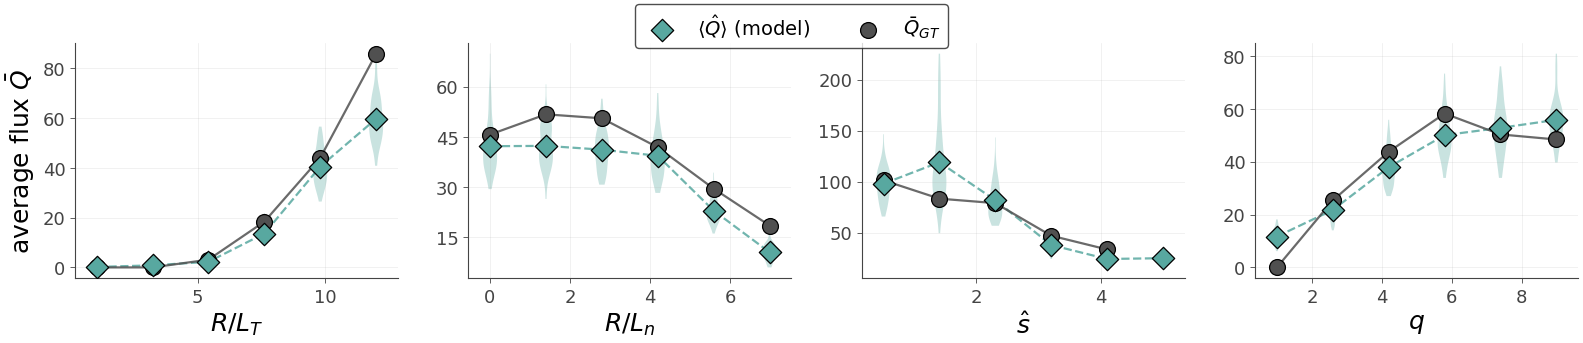

In [8]:
# === flux-resample diagnostic — violin plot (q, shat, rlt, rln) ===========
# Pure plotting cell — consumes globals()["scan_data"] populated by the
# sampling cell above. Each iteration shows: violin + diamond for the
# predicted-flux distribution and an orange circle for the GT-tail mean.
# Lines connect the predicted means and GT points across iterations so both
# trajectories are visible per panel.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator as _MaxN

if "scan_data" not in globals():
    raise RuntimeError("scan_data missing — run the scan-sample cell first")

PANELS_V = ["rlt", "rln", "shat", "q"]
PANEL_LABEL_V = {
    "rlt":  r"$R/L_T$",
    "rln":  r"$R/L_n$",
    "shat": r"$\hat{s}$",
    "q":    r"$q$",
}
COLOR_SCAN = COLOR_GYROFLOW          # teal — our method
COLOR_GT   = COLOR_GKW               # neutral grey — reference solver

apply_paper_style()
fig, axes = plt.subplots(1, 4, figsize=(16.0, 3.5), squeeze=False)

for col_i, param in enumerate(PANELS_V):
    ax = axes[0, col_i]
    rows = sorted(scan_data.get(param, []), key=lambda r: r["x"])
    if not rows:
        ax.set_xlabel(PANEL_LABEL_V[param], fontsize=18); continue

    xs = np.array([r["x"] for r in rows])
    span = (xs.max() - xs.min()) if xs.size > 1 else 1.0
    width = 0.05 * max(span, 1e-6)

    pred_means = np.array([float(np.nanmean(r["samples"])) if np.isfinite(r["samples"]).any() else np.nan for r in rows])
    gts        = np.array([r["gt"] for r in rows], dtype=float)
    m_pred = np.isfinite(pred_means)
    m_gt   = np.isfinite(gts)

    if m_pred.any():
        ax.plot(xs[m_pred], pred_means[m_pred], color=COLOR_SCAN, lw=1.6, ls="--", alpha=0.85, zorder=3)
    if m_gt.any():
        ax.plot(xs[m_gt], gts[m_gt], color=COLOR_GT, lw=1.6, ls="-", alpha=0.85, zorder=3)

    for r in rows:
        finite = r["samples"][np.isfinite(r["samples"])]
        if finite.size >= 3 and finite.std() > 0:
            parts = ax.violinplot(finite, positions=[r["x"]], widths=width,
                                    showmeans=False, showmedians=False, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(COLOR_SCAN); pc.set_edgecolor("none"); pc.set_alpha(0.32)
        if finite.size:
            ax.scatter([r["x"]], [float(finite.mean())],
                        s=130, facecolor=COLOR_SCAN, edgecolor="black",
                        lw=0.9, marker="D", zorder=5)
        if np.isfinite(r["gt"]):
            ax.scatter([r["x"]], [r["gt"]],
                        s=130, facecolor=COLOR_GT, edgecolor="black",
                        lw=0.9, marker="o", zorder=4)

    ax.set_xlabel(PANEL_LABEL_V[param], fontsize=18)
    if col_i == 0:
        ax.set_ylabel(r"average flux $\bar{Q}$", fontsize=18)
    ax.tick_params(axis="both", labelsize=13)
    ax.yaxis.set_major_locator(_MaxN(5))
    ax.grid(alpha=0.25)

_h_pred = axes[0, 0].scatter([], [], s=130, facecolor=COLOR_SCAN, edgecolor="black", lw=0.9, marker="D")
_h_gt   = axes[0, 0].scatter([], [], s=130, facecolor=COLOR_GT,   edgecolor="black", lw=0.9, marker="o")
fig.legend([_h_pred, _h_gt], [r"$\langle\hat{Q}\rangle$ (model)", r"$\bar{Q}_{GT}$"],
            loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2,
            fontsize=14, frameon=True, edgecolor=COLOR_REF)

fig.tight_layout(rect=(0, 0, 1, 0.92))
try:    save_fig(fig, "param_scans_diag", RESULTS_DIR)
except Exception: pass
plt.show()

  expanding to 289 training trajectories
  parsed 151920 flux samples across 211 trajectories


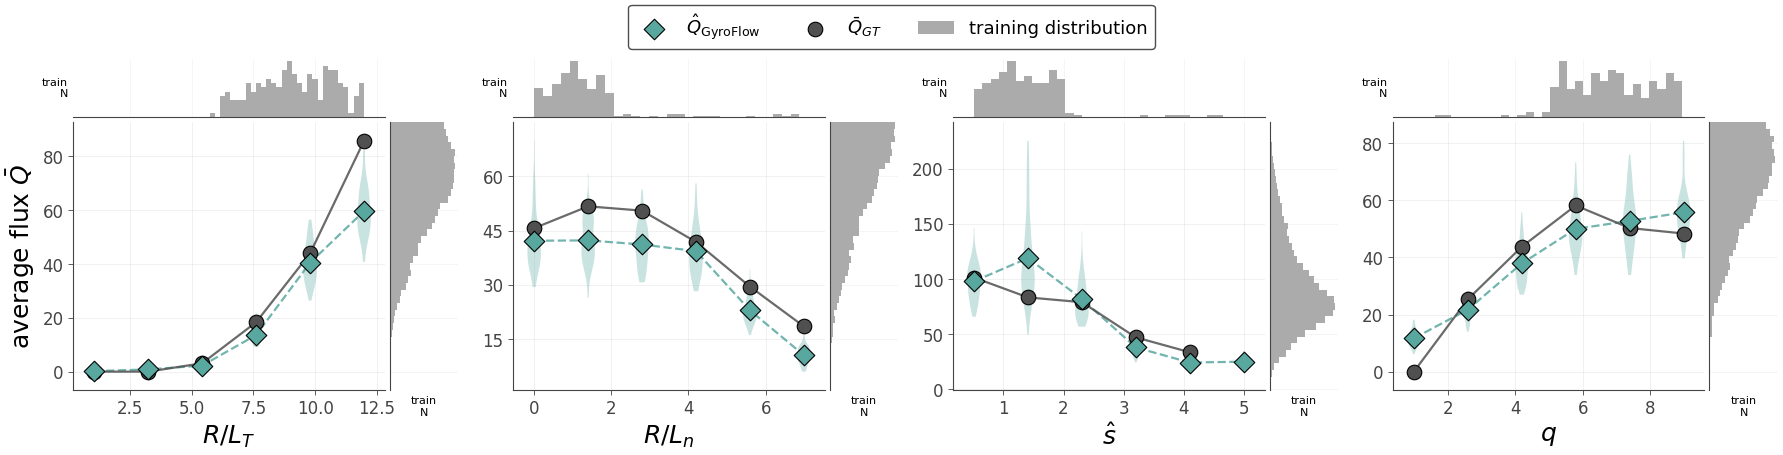

In [16]:
# === param-scan + training-set marginals (4 panels with side histograms) =====
# Same scan_data as the violin plot above, augmented with marginal histograms
# of the training-set parameter distribution (top strip) and saturated flux
# distribution (right strip). Training data is parsed from raw GKW
# /restricteddata/ukaea/gyrokinetics/raw/iteration_<N>/{input.dat,fluxes.dat},
# applying the same first_fluxes/last_fluxes >= 1.0 filter as the training
# config (configs/dataset/cyclone_full.yaml) so the marginal matches the
# trajectories the model actually saw.
import os, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator as _MaxN
from mpl_toolkits.axes_grid1 import make_axes_locatable
from neugk.utils import parse_input_dat

if "scan_data" not in globals():
    raise RuntimeError("scan_data missing — run the scan-sample cell first")

# --- training-trajectory list ----------------------------------------------
def _expand_ranges(spec_ranges):
    out = []
    for lo, hi in spec_ranges: out.extend(range(lo, hi + 1))
    return out

TRAIN_RANGES = [
    (0, 7), (9, 12), (14, 64), (67, 99), (101, 114), (116, 130),
    (132, 147), (149, 199), (201, 234), (236, 261), (263, 299),
]
TRAIN_IDS = _expand_ranges(TRAIN_RANGES)
print(f"  expanding to {len(TRAIN_IDS)} training trajectories")

# --- parse params + saturated flux from raw GKW ---------------------------
RAW_ROOT     = "/restricteddata/ukaea/gyrokinetics/raw"
SAT_OFFSET   = 80             # transient cutoff: indices < 80 are pre-saturation
PARAM_KEY    = {"rlt": ("species","rlt"), "rln":("species","rln"),
                "shat":("geom","shat"), "q":("geom","q")}

train = {p: {"x": [], "flux": []} for p in PARAM_KEY}
flux_pool = []                 # all training fluxes pooled (for the right strip)

for n in TRAIN_IDS:
    d = os.path.join(RAW_ROOT, f"iteration_{n}")
    inp = os.path.join(d, "input.dat")
    flx = os.path.join(d, "fluxes.dat")
    if not (os.path.isfile(inp) and os.path.isfile(flx)):
        continue
    try:
        cfg = parse_input_dat(inp)
        fl  = np.loadtxt(flx)
    except Exception as e:
        print(f"  skip iteration_{n}: {type(e).__name__}: {e}")
        continue
    if fl.ndim == 2 and fl.shape[1] >= 2:
        col = fl[:, 1]
    elif fl.ndim == 1:
        col = fl
    else:
        continue
    if col.shape[0] <= SAT_OFFSET: continue
    # Apply training_cond_filters from configs/dataset/cyclone_full.yaml:
    #   first_fluxes  = mean over the first SAT_OFFSET (transient) samples
    #   last_fluxes   = mean over the last  SAT_OFFSET samples
    # Both must be >= 1.0 for the trajectory to enter the training set.
    first_flux = float(np.nanmean(col[:SAT_OFFSET]))
    last_flux  = float(np.nanmean(col[-SAT_OFFSET:]))
    if not (first_flux >= 1.0 and last_flux >= 1.0):
        continue
    tail = col[SAT_OFFSET:]
    tail = tail[np.isfinite(tail)]
    if not tail.size: continue
    flux_pool.append(tail)
    for p, (sec, key) in PARAM_KEY.items():
        try:
            v = float(cfg[sec][key])
        except Exception:
            continue
        train[p]["x"].append(v)
        train[p]["flux"].append(float(np.mean(tail)))    # mean per trajectory

flux_pool = np.concatenate(flux_pool) if flux_pool else np.array([])
print(f"  parsed {len(flux_pool)} flux samples across {sum(len(train[p]["x"]) for p in PARAM_KEY)//4} trajectories")

# --- plot: 4 panels with top + right marginals ----------------------------
PANELS = ["rlt", "rln", "shat", "q"]
PANEL_LABEL = {"rlt": r"$R/L_T$", "rln": r"$R/L_n$", "shat": r"$\hat{s}$", "q": r"$q$"}
COLOR_SCAN = COLOR_GYROFLOW
COLOR_GT   = COLOR_GKW
COLOR_HIST = "#888888"

apply_paper_style()
fig, axes = plt.subplots(1, 4, figsize=(18.0, 4.5), squeeze=False)
plt.subplots_adjust(wspace=0.55)

# Per-panel y-range is derived from that panel's scan dots (pred mean + GT),
# not from the training-flux distribution; histograms are clipped accordingly.

for col_i, param in enumerate(PANELS):
    ax = axes[0, col_i]
    rows = sorted(scan_data.get(param, []), key=lambda r: r["x"])
    if not rows:
        ax.set_xlabel(PANEL_LABEL[param], fontsize=18); continue

    xs = np.array([r["x"] for r in rows])
    span = (xs.max() - xs.min()) if xs.size > 1 else 1.0
    width = 0.05 * max(span, 1e-6)
    pred_means = np.array([float(np.nanmean(r["samples"])) if np.isfinite(r["samples"]).any() else np.nan for r in rows])
    gts = np.array([r["gt"] for r in rows], dtype=float)
    m_pred = np.isfinite(pred_means); m_gt = np.isfinite(gts)

    if m_pred.any():
        ax.plot(xs[m_pred], pred_means[m_pred], color=COLOR_SCAN, lw=1.6, ls="--", alpha=0.85, zorder=3)
    if m_gt.any():
        ax.plot(xs[m_gt], gts[m_gt], color=COLOR_GT, lw=1.6, ls="-", alpha=0.85, zorder=3)
    for r in rows:
        finite = r["samples"][np.isfinite(r["samples"])]
        if finite.size >= 3 and finite.std() > 0:
            parts = ax.violinplot(finite, positions=[r["x"]], widths=width,
                                  showmeans=False, showmedians=False, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(COLOR_SCAN); pc.set_edgecolor("none"); pc.set_alpha(0.32)
        if finite.size:
            ax.scatter([r["x"]], [float(finite.mean())], s=110, facecolor=COLOR_SCAN,
                       edgecolor="black", lw=0.8, marker="D", zorder=5)
        if np.isfinite(r["gt"]):
            ax.scatter([r["x"]], [r["gt"]], s=110, facecolor=COLOR_GT,
                       edgecolor="black", lw=0.8, marker="o", zorder=4)

    ax.set_xlabel(PANEL_LABEL[param], fontsize=18)
    if col_i == 0:
        ax.set_ylabel(r"average flux $\bar{Q}$", fontsize=18)
    ax.tick_params(axis="both", labelsize=12)
    ax.yaxis.set_major_locator(_MaxN(5))
    # Y-limits per panel: include scan dots (pred-mean + GT) AND the finite
    # extrema of the per-iteration violins, so the high tail of each
    # iteration is visible.
    finite_violin_lo = []
    finite_violin_hi = []
    for r in rows:
        s = np.asarray(r["samples"], dtype=float)
        s = s[np.isfinite(s)]
        if s.size:
            finite_violin_lo.append(float(s.min()))
            finite_violin_hi.append(float(s.max()))
    pool = np.concatenate([pred_means[m_pred], gts[m_gt],
                           np.asarray(finite_violin_lo, dtype=float),
                           np.asarray(finite_violin_hi, dtype=float)])
    if pool.size:
        ymin_p = float(pool.min())
        ymax_p = float(pool.max())
        pad    = 0.08 * max(ymax_p - ymin_p, 1e-3)
        ax.set_ylim(ymin_p - pad, ymax_p + pad)
    ymin_pan, ymax_pan = ax.get_ylim()
    ax.grid(alpha=0.25)

    # Marginals via axes divider
    div = make_axes_locatable(ax)
    ax_top   = div.append_axes("top",   size="22%", pad=0.05, sharex=ax)
    ax_right = div.append_axes("right", size="22%", pad=0.05, sharey=ax)

    # Top: training distribution of the swept parameter
    train_p = np.asarray(train[param]["x"], dtype=float)
    if train_p.size:
        ax_top.hist(train_p, bins=30, color=COLOR_HIST, edgecolor="none", alpha=0.7)
    ax_top.set_yticks([])
    ax_top.tick_params(axis="x", labelbottom=False, length=0)
    for s in ("top", "right", "left"): ax_top.spines[s].set_visible(False)
    ax_top.set_ylabel("train\nN", fontsize=8, rotation=0, ha="right", va="center")

    # Right: training flux distribution (last 240 steps pooled across all trajectories)
    if flux_pool.size:
        clipped = flux_pool[(flux_pool >= ymin_pan) & (flux_pool <= ymax_pan)]
        if clipped.size:
            ax_right.hist(clipped, bins=40, orientation="horizontal",
                          range=(ymin_pan, ymax_pan),
                          color=COLOR_HIST, edgecolor="none", alpha=0.7)
    ax_right.set_xticks([])
    ax_right.tick_params(axis="y", labelleft=False, length=0)
    for s in ("top", "right", "bottom"): ax_right.spines[s].set_visible(False)
    ax_right.set_xlabel("train\nN", fontsize=8)

# top legend
_h_pred = axes[0, 0].scatter([], [], s=110, facecolor=COLOR_SCAN, edgecolor="black", lw=0.8, marker="D")
_h_gt   = axes[0, 0].scatter([], [], s=110, facecolor=COLOR_GT,   edgecolor="black", lw=0.8, marker="o")
_h_tr   = plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_HIST, alpha=0.7, edgecolor="none")
fig.legend([_h_pred, _h_gt, _h_tr],
           [r"$\hat{Q}_{\mathrm{GyroFlow}}$", r"$\bar{Q}_{GT}$", "training distribution"],
           loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3,
           fontsize=13, frameon=True, edgecolor=COLOR_REF)

fig.tight_layout(rect=(0, 0, 1, 0.93))
try:    save_fig(fig, "param_scans_diag_with_marginals", RESULTS_DIR)
except Exception: pass
plt.show()


In [10]:
N_GT_TAIL_NEW    = 3 * 80
GT_SUBSAMPLE_NEW = 1
RAW_KYSPEC_TO_INTEGRATOR = globals().get("RAW_KYSPEC_TO_INTEGRATOR", 16.0)

n_updated = 0
for traj, res in warm_results.items():
    if traj.startswith("ood_iteration_"):
        gkw_path = os.path.join(GKW_RAW_DIR, "ood", traj[len("ood_"):])
    else:
        gkw_path = os.path.join(GKW_RAW_DIR, traj)
    log_gt_ref = {}
    fluxes_p = os.path.join(gkw_path, "fluxes.dat")
    if os.path.isfile(fluxes_p):
        ref = np.loadtxt(fluxes_p)[::GT_SUBSAMPLE_NEW, 1][-N_GT_TAIL_NEW:]
        res["ref_flux_samples"] = np.asarray(ref, dtype=np.float64)
    kyspec_p = os.path.join(gkw_path, "kyspec")
    if os.path.isfile(kyspec_p):
        log_gt_ref["ky_spec"] = (np.loadtxt(kyspec_p)[::GT_SUBSAMPLE_NEW][-N_GT_TAIL_NEW:]
                                  * RAW_KYSPEC_TO_INTEGRATOR)
    eflux_p = os.path.join(gkw_path, "eflux_spectra.dat")
    if os.path.isfile(eflux_p):
        log_gt_ref["fluxspec"] = (np.loadtxt(eflux_p)[::GT_SUBSAMPLE_NEW][-N_GT_TAIL_NEW:])
    time_p = os.path.join(gkw_path, "time.dat")
    if os.path.isfile(time_p):
        log_gt_ref["time"] = np.loadtxt(time_p)[::GT_SUBSAMPLE_NEW][-N_GT_TAIL_NEW:]
    res["log_gt_ref"] = log_gt_ref
    n_updated += 1

print(f"refreshed log_gt_ref on {n_updated} traj(s) "
       f"(N_GT_TAIL={N_GT_TAIL_NEW}, GT_SUBSAMPLE={GT_SUBSAMPLE_NEW})")
print("--- new reference shapes ---")
for traj, res in list(warm_results.items())[:2]:
    log_gt = res["log_gt_ref"]
    print(f"  {traj}: ref_flux={getattr(res.get('ref_flux_samples'), 'shape', None)}  "
          f"ky_spec={getattr(log_gt.get('ky_spec'), 'shape', None)}  "
          f"fluxspec={getattr(log_gt.get('fluxspec'), 'shape', None)}")

refreshed log_gt_ref on 11 traj(s) (N_GT_TAIL=240, GT_SUBSAMPLE=1)
--- new reference shapes ---
  iteration_262: ref_flux=(240,)  ky_spec=(240, 32)  fluxspec=(240, 32)
  iteration_135: ref_flux=(240,)  ky_spec=(240, 32)  fluxspec=(240, 32)


In [ ]:
# === post-hoc: distributional divergences over stored warm logs ============
# Re-runnable. compute_distribution_divergences detects `<k>_per_restart`
# arrays in log_warm and pools restarts along time for the headline metric,
# while also reporting per-restart spread (mean ± std).
from importlib import reload
import neurips_warm_restarts as _nwr
reload(_nwr)
from neurips_warm_restarts import compute_distribution_divergences

WARM_FRAC = 0.95
NORMALIZE_SPECTRA = True

PRINT_KEYS = (
    "flux_w1", "flux_mmd", "flux_ks_d", "flux_ad",
    "ky_spec_w1_mean", "ky_spec_mmd_mean", "ky_spec_ks_d_mean", "ky_spec_ad_mean",
    "fluxspec_w1_mean", "fluxspec_mmd_mean", "fluxspec_ks_d_mean", "fluxspec_ad_mean",
)

for traj, res in warm_results.items():
    lw = res.get("log_warm", {})
    eflux = np.asarray(lw.get("eflux", []))
    if eflux.size == 0:
        continue
    n_r = lw.get("n_restarts", 1)
    gt = res.get("ref_flux_samples")

for traj, res in warm_results.items():
    log_warm = res.get("log_warm")
    if not log_warm or "eflux" not in log_warm:
        res["div_warm"] = {}
        continue
    res["div_warm"] = compute_distribution_divergences(
        log_warm,
        res.get("log_gt_ref", {}),
        ref_flux_samples=res.get("ref_flux_samples"),
        warm_frac=WARM_FRAC,
        normalize_spectra=NORMALIZE_SPECTRA,
    )

## 4. Distributional divergences: warm vs GT-saturated state

The **warm trajectory is short** (∼1k solver steps) and may sit anywhere
on the attractor — it does *not* track the long GT trajectory pointwise.
We therefore compare the warm run's stationary window (default last 50% of
the run) against the **GT saturated-state distribution**:

* **flux**: last 240 rows of `fluxes.dat` (column 2; loaded by
  `load_reference_flux_samples`, equivalent to the last 80 snapshots since
  fluxes.dat is sampled 3× more frequently than the snapshot grid).
* **spectra (kyspec, fluxspec)**: last `N_GT_TAIL_SPEC=80` snapshots from
  the preprocessed `metadata.pkl` of `iteration_{i}_ifft_realpotens`.

The driver `compute_distribution_divergences` runs every paper-spec test —
KS, AD, Wasserstein, Gelman–Rubin R̂, autocorrelation/structure-fn — plus
Wilcoxon (Mann–Whitney rank-sum + signed-rank), MMD-RBF, energy distance,
mean-log-spectrum Pearson/L2, time-averaged-spectrum KL, and the paper's
τ_Q first-passage times. All variants are scored *only on the warm run*;
TTC has been removed.

In [ ]:
# Warm-vs-GT divergences across iterations: rows = (iter, metric), cols = value.
# Skip non-scalar entries (the `_per_restart` lists added by the multi-restart
# pooling) and the `_per_restart_mean/std` companion summaries to keep this
# headline pivot strictly numeric.
rows = []
for it, res in warm_results.items():
    for k, v in res["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        rows.append({"iter": it, "metric": k, "value": float(v)})
divergence_long = pd.DataFrame(rows)
divergence_pivot = divergence_long.pivot(index="metric", columns="iter", values="value")
divergence_pivot["mean"]   = divergence_pivot.mean(axis=1)
divergence_pivot["median"] = divergence_pivot.median(axis=1)
divergence_pivot["std"]    = divergence_pivot.std(axis=1)
divergence_pivot = divergence_pivot.sort_values("mean", ascending=True)
print("Warm-run divergences vs GT saturated state (one column per iter, sorted by mean):")
print(divergence_pivot.to_string(float_format=lambda x: f"{x:.4g}"))
divergence_pivot


In [ ]:
PRUNE_STD_THRESHOLD = 1e-4

M_full = divergence_pivot.drop(columns=[c for c in ("mean", "median", "std")
                                          if c in divergence_pivot.columns])
all_metrics = list(M_full.index)
traj_names  = list(M_full.columns)

FAMILIES    = ("flux", "ky_spec", "fluxspec")
FAMILY_CMAP = {
    "flux":     "Reds",
    "ky_spec":  "Blues",
    "fluxspec": "Oranges",
}
INTRA_CMAP = "RdBu_r"

def _family(m):
    for f in FAMILIES:
        if m.startswith(f + "_"): return f
    return "other"

def _type(m, f):
    return m[len(f) + 1:] if m.startswith(f + "_") else m

# ---- prune NaN / near-constant metrics across trajs --------------------
kept, pruned = [], []
for m in all_metrics:
    v = M_full.loc[m].to_numpy(dtype=float)
    finite = v[np.isfinite(v)]
    if finite.size < 2:
        pruned.append((m, "few finite")); continue
    if finite.std() <= PRUNE_STD_THRESHOLD * (abs(finite.mean()) + 1e-30):
        pruned.append((m, f"near-constant std={finite.std():.2e}")); continue
    kept.append(m)
if pruned:
    print(f"pruned {len(pruned)}/{len(all_metrics)} metrics:")
    for m, reason in pruned[:30]:
        print(f"  - {m}: {reason}")
    if len(pruned) > 30:
        print(f"  … and {len(pruned) - 30} more")

# ---- group ---------------------------------------------------------------
families_metrics = {f: [m for m in kept if _family(m) == f] for f in FAMILIES}
families_metrics = {f: ms for f, ms in families_metrics.items() if ms}

# ---- per-family figure: (left) metric × traj heatmap (row-normalised),
#                         (right) metric × metric Pearson r (cluster spotting)
for fam, ms in families_metrics.items():
    cmap_traj = FAMILY_CMAP.get(fam, "Greys")
    short = [_type(m, fam) for m in ms]

    # Panel 1: metric × traj, row-normalised so each metric is comparable.
    M = M_full.loc[ms].to_numpy(dtype=float)
    M_norm = np.zeros_like(M)
    for i in range(M.shape[0]):
        finite = M[i][np.isfinite(M[i])]
        if finite.size == 0:
            continue
        lo, hi = finite.min(), finite.max()
        rng = max(hi - lo, 1e-12)
        M_norm[i, :] = (M[i, :] - lo) / rng

    # Panel 2: intra-family metric × metric Pearson r across trajs.
    K = len(ms)
    R = np.full((K, K), np.nan)
    for i in range(K):
        for j in range(K):
            xi = M[i]; xj = M[j]
            mask = np.isfinite(xi) & np.isfinite(xj)
            if mask.sum() < 3 or np.std(xi[mask]) == 0 or np.std(xj[mask]) == 0:
                continue
            R[i, j] = float(np.corrcoef(xi[mask], xj[mask])[0, 1])

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(8, 0.45 * (len(traj_names) + K)), max(3, 0.34 * K)),
        gridspec_kw={"width_ratios": [max(1, len(traj_names)), max(1, K)],
                     "wspace": 0.35},
    )

    # left: metric × traj
    im0 = axes[0].imshow(M_norm, cmap=cmap_traj, aspect="auto", vmin=0, vmax=1)
    axes[0].set_yticks(range(K)); axes[0].set_yticklabels(short, fontsize=8)
    axes[0].set_xticks(range(len(traj_names)))
    axes[0].set_xticklabels([str(t) for t in traj_names], rotation=30, ha="right", fontsize=8)
    for i in range(K):
        for j in range(len(traj_names)):
            v = M[i, j]
            if np.isfinite(v):
                axes[0].text(j, i, f"{v:.2g}", ha="center", va="center",
                             fontsize=6,
                             color="black" if 0.25 < M_norm[i, j] < 0.75 else "white")
    axes[0].set_title(f"{fam}: divergence per (metric, traj) — row-normalised",
                       fontsize=10, fontweight="bold")
    plt.colorbar(im0, ax=axes[0], fraction=0.04, pad=0.02, label="row-normalised")

    # right: metric × metric Pearson r
    im1 = axes[1].imshow(R, cmap=INTRA_CMAP, aspect="equal", vmin=-1, vmax=1)
    axes[1].set_xticks(range(K)); axes[1].set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    axes[1].set_yticks(range(K)); axes[1].set_yticklabels(short, fontsize=8)
    for i in range(K):
        for j in range(K):
            v = R[i, j]
            if np.isfinite(v):
                axes[1].text(j, i, f"{v:+.2f}", ha="center", va="center",
                             fontsize=6,
                             color="white" if abs(v) > 0.5 else "black")
    axes[1].set_title(f"{fam}: metric × metric Pearson r  "
                       "(blocks of red ⇒ redundant cluster)",
                       fontsize=10, fontweight="bold")
    plt.colorbar(im1, ax=axes[1], fraction=0.04, pad=0.02, label="Pearson r")

    fig.suptitle(f"family: {fam}   ({K} metrics across {len(traj_names)} trajs)",
                 fontsize=12, fontweight="bold", y=1.0)
    fig.tight_layout()

if gs_fid_per_source:
    print("\nGlobal GyroSwin FID per source (constant across trajs):")
    for src, v in gs_fid_per_source.items():
        print(f"  {src:20s}  FID = {v:.4f}")


In [ ]:
import numpy as np
import pandas as pd

apply_paper_style()
per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
if not per_iter_fids:
    raise RuntimeError("run `latent_dashboard` first to populate per_iter_fids")


def _flux_rmse_meant(res):
    """Time-averaged warm flux vs time-averaged GT flux. Per-restart RMSE
    when the warm log carries `eflux_per_restart`; otherwise the absolute
    difference of the two means."""
    log_w = res.get("log_warm", {}) or {}
    ref = res.get("ref_flux_samples")
    if ref is None or len(np.asarray(ref).ravel()) == 0:
        return np.nan
    gt_mean = float(np.mean(np.asarray(ref, dtype=float)))
    if "eflux_per_restart" in log_w:
        e = np.asarray(log_w["eflux_per_restart"], dtype=float)
        T = e.shape[1]
        e_late = e[:, T // 2:]
        per_r = e_late.mean(axis=1)
        return float(np.sqrt(np.mean((per_r - gt_mean) ** 2)))
    if "eflux" in log_w:
        e = np.asarray(log_w["eflux"], dtype=float)
        warm_mean = float(e[len(e) // 2:].mean()) if e.size else np.nan
        return abs(warm_mean - gt_mean)
    return np.nan


# --- 2-D MMD reference: read from div_warm[<fam>_mmd2d], populated by
#     `compute_distribution_divergences` (joint-over-modes RBF kernel,
#     captures cross-mode correlations the per-mode `*_mmd_mean` cannot).
def _mmd2d_per_traj(res, fam):
    return float((res.get("div_warm", {}) or {}).get(f"{fam}_mmd2d", np.nan))


trajs  = sorted(per_iter_fids.keys())
levels = sorted({lv for d in per_iter_fids.values() for lv in d})
M = np.array([[per_iter_fids[t].get(lv, np.nan) for t in trajs] for lv in levels],
              dtype=float)

# --- (a) per-(level, traj) heatmap ----------------------------------------
fig, ax = plt.subplots(figsize=(max(5.5, 0.55 * len(trajs)),
                                 max(2.4, 0.5 * len(levels))))
im = ax.imshow(M, cmap="viridis", aspect="auto")
ax.set_yticks(range(len(levels)));  ax.set_yticklabels(levels)
ax.set_xticks(range(len(trajs)));   ax.set_xticklabels(trajs, rotation=30, ha="right")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2g}", ha="center", va="center", fontsize=7,
                     color="white" if v > np.nanmedian(M) else "black")
ax.set_title("FGyD per U-Net level × trajectory", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="FGyD")
fig.tight_layout()
save_fig(fig, "fid_heatmap_per_level_traj", RESULTS_DIR)
plt.show()

# --- (traj × {levels, flux_rmse_meant, mmd2d}) DataFrame ------------------
fid_df = pd.DataFrame({lv: [per_iter_fids[t].get(lv, np.nan) for t in trajs]
                        for lv in levels}, index=trajs)
flux_rmse = pd.Series(
    [_flux_rmse_meant(warm_results.get(t, {})) for t in trajs],
    index=trajs, name="flux_rmse_meant",
)
print("=== flux_rmse_meant per traj ===")
print(flux_rmse.to_string(float_format=lambda x: f"{x:.4f}"))

mmd2d_ky    = pd.Series([_mmd2d_per_traj(warm_results.get(t, {}), "ky_spec")  for t in trajs],
                          index=trajs, name="mmd2d_W(ky)")
mmd2d_qspec = pd.Series([_mmd2d_per_traj(warm_results.get(t, {}), "fluxspec") for t in trajs],
                          index=trajs, name="mmd2d_Q(ky)")
print("\n=== 2-D MMD (joint over modes) per traj ===")
print(pd.concat([mmd2d_ky, mmd2d_qspec], axis=1)
        .to_string(float_format=lambda x: f"{x:.4f}"))

fid_df_aug = pd.concat([fid_df, flux_rmse, mmd2d_ky, mmd2d_qspec], axis=1)
print("\n=== values per (traj × {level, flux_rmse_meant, mmd2d}) ===")
print(fid_df_aug.to_string(float_format=lambda x: f"{x:.4f}"))

# Cross-correlation including the flux_rmse_meant + 2-D MMD entries.
corr = fid_df_aug.corr(method="pearson")
print("\n=== Cross-level Pearson r (FIDs + flux_rmse + 2-D MMD) ===")
print(corr.to_string(float_format=lambda x: f"{x:+.3f}"))

# --- (b) cross-level Pearson heatmap --------------------------------------
labels = list(fid_df_aug.columns)
fig, ax = plt.subplots(figsize=(0.7 * len(labels) + 1.5,
                                 0.7 * len(labels) + 1.0))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(v) > 0.6 else "black")
# highlight the flux_rmse_meant + 2-D MMD rows/cols with darker frames
n = len(labels)
for r_idx in range(n - 3, n):
    ax.add_patch(plt.Rectangle((-0.5, r_idx - 0.5), n, 1,
                                 fill=False, edgecolor=COLOR_FLUX, lw=1.2))
    ax.add_patch(plt.Rectangle((r_idx - 0.5, -0.5), 1, n,
                                 fill=False, edgecolor=COLOR_FLUX, lw=1.2))
ax.set_title("Pearson r across trajs: FGyD levels + flux RMSE + 2-D MMD", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Pearson r")
fig.tight_layout()
save_fig(fig, "fid_cross_level_corr", RESULTS_DIR)
plt.show()

# --- (c) per-level scatter: flux RMSE (physics baseline) vs FID -----------
from matplotlib.ticker import MaxNLocator
import matplotlib as _mpl

fr = flux_rmse.to_numpy(dtype=float)
trajs_idx = list(fid_df.index)
_traj_cmap = _mpl.colormaps.get_cmap("tab10")
traj_colors = {t: _traj_cmap(i % 10) for i, t in enumerate(trajs_idx)}

fig2, axes2 = plt.subplots(1, len(levels),
                            figsize=(3.0 * len(levels), 3.2),
                            sharey=True, squeeze=False)
scatter_handles = []
for col_i, (ax2, lv) in enumerate(zip(axes2[0], levels)):
    f_v = fid_df[lv].to_numpy(dtype=float)
    mask = np.isfinite(f_v) & np.isfinite(fr)
    if mask.sum() >= 3 and np.std(f_v[mask]) > 0 and np.std(fr[mask]) > 0:
        r = float(np.corrcoef(f_v[mask], fr[mask])[0, 1])
        r2 = r ** 2
    else:
        r = np.nan; r2 = np.nan
    for j, t in enumerate(trajs_idx):
        if not mask[j]:
            continue
        h = ax2.scatter(f_v[j], fr[j], s=46, color=traj_colors[t],
                          edgecolor="black", lw=0.6, alpha=0.95,
                          label=t if col_i == 0 else None)
        if col_i == 0:
            scatter_handles.append((t, h))
    ax2.set_xlabel(f"FGyD({lv})", fontsize=12)
    ax2.set_title(f"r={r:+.2f}  R²={r2:.2f}" if np.isfinite(r) else "n/a",
                    fontsize=12)
    ax2.tick_params(axis="both", labelsize=11)
    ax2.xaxis.set_major_locator(MaxNLocator(4))
    ax2.yaxis.set_major_locator(MaxNLocator(4))
    ax2.grid(alpha=0.25)
axes2[0, 0].set_ylabel(r"flux RMSE  $|\langle Q\rangle_\mathrm{warm}-\langle Q\rangle_\mathrm{GT}|$",
                         fontsize=12)
fig2.suptitle("Time-averaged flux RMSE vs FGyD per U-Net level",
                fontsize=13, y=1.02)
handles = [h for (_, h) in scatter_handles]
labels  = [t for (t, _) in scatter_handles]
leg = fig2.legend(handles, labels, loc="lower center", ncol=len(labels),
                    bbox_to_anchor=(0.5, -0.02), fontsize=10,
                    frameon=True, fancybox=False, edgecolor=COLOR_REF)
leg.get_frame().set_linewidth(0.8)
fig2.tight_layout(rect=(0, 0.05, 1, 0.97))
save_fig(fig2, "fluxrmse_vs_fid_per_level", RESULTS_DIR)
plt.show()

# Persist for the cross-method comparison notebook.
PAPER_FID_LANDSCAPE = {
    "fid_per_level_traj":    fid_df.to_dict(),
    "flux_rmse_meant":       flux_rmse.to_dict(),
    "mmd2d_ky_spec":         mmd2d_ky.to_dict(),
    "mmd2d_fluxspec":        mmd2d_qspec.to_dict(),
    "fid_cross_level_corr":  corr.to_dict(),
}


In [ ]:
import numpy as np
import pandas as pd

_ns = globals()
_pif = _ns.get("per_iter_fids")
_warm = _ns.get("warm_results", {})
if not _pif:
    raise RuntimeError("per_iter_fids is empty or undefined — run the "
                        "`latent_dashboard` cell first.")
per_iter_fids = _pif


def _flux_rmse_meant(res):
    """RMSE of the time-averaged warm flux against the time-averaged GT flux.
    Uses per-restart traces when available so the RMSE has > 1 sample."""
    log_w = res.get("log_warm", {}) or {}
    ref = res.get("ref_flux_samples")
    if ref is None or len(np.asarray(ref).ravel()) == 0:
        return np.nan
    gt_mean = float(np.mean(np.asarray(ref, dtype=float)))
    if "eflux_per_restart" in log_w:
        e = np.asarray(log_w["eflux_per_restart"], dtype=float)  # (R, T)
        T = e.shape[1]
        e_late = e[:, T // 2:]                                    # post-sat half
        per_r_mean = e_late.mean(axis=1)                          # (R,)
        diffs = per_r_mean - gt_mean
        return float(np.sqrt(np.mean(diffs ** 2)))
    if "eflux" in log_w:
        e = np.asarray(log_w["eflux"], dtype=float)
        warm_mean = float(e[len(e) // 2:].mean()) if e.size else np.nan
        return abs(warm_mean - gt_mean)
    return np.nan


# Build per-traj table of metrics + FIDs.
rows = []
for traj, fids in per_iter_fids.items():
    if traj not in warm_results or not warm_results[traj].get("div_warm"):
        continue
    row = {"traj": traj, "split": warm_results[traj].get("split", "ID")}
    for lv, v in fids.items():
        row[f"FID_{lv}"] = v
    for k, v in warm_results[traj]["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        row[k] = v
    # Physics baseline: time-averaged flux RMSE.
    row["flux_rmse_meant"] = _flux_rmse_meant(warm_results[traj])
    rows.append(row)

if len(rows) < 3:
    print(f"only {len(rows)} trajs with both FID + divergences — Pearson r needs >= 3")
else:
    corr_df = pd.DataFrame(rows)
    fid_cols = [c for c in corr_df.columns if c.startswith("FID_")]
    raw_metric_cols = [c for c in corr_df.columns
                       if c not in (["traj", "split"] + fid_cols)]

    FAMILY_ORDER = ("flux", "ky_spec", "fluxspec", "other")
    TYPE_ORDER   = ("rmse_meant",
                    "w1", "w1_mean", "mmd", "mmd_mean",
                    "ks_p", "ks_p_mean",
                    "ad", "ad_mean",
                    "arima_l2", "arima_l2_mean",
                    "r2_hist", "r2_meanlog")

    def _family(name):
        if name.startswith("flux_"):     return "flux"
        if name.startswith("ky_spec_"):  return "ky_spec"
        if name.startswith("fluxspec_"): return "fluxspec"
        return "other"
    def _type(name, fam):
        if fam == "flux":     return name[len("flux_"):]
        if fam == "ky_spec":  return name[len("ky_spec_"):]
        if fam == "fluxspec": return name[len("fluxspec_"):]
        return name
    def _sort_key(name):
        fam = _family(name); typ = _type(name, fam)
        fam_idx = FAMILY_ORDER.index(fam) if fam in FAMILY_ORDER else len(FAMILY_ORDER)
        typ_idx = TYPE_ORDER.index(typ) if typ in TYPE_ORDER else len(TYPE_ORDER) + hash(typ) % 1000
        return (fam_idx, typ_idx, name)

    metric_cols = sorted(raw_metric_cols, key=_sort_key)
    metric_families = [_family(m) for m in metric_cols]
    fam_label_pos = {}
    for fam in FAMILY_ORDER:
        idxs = [i for i, f in enumerate(metric_families) if f == fam]
        if idxs:
            fam_label_pos[fam] = (idxs[0], idxs[-1])

    corr_matrix = pd.DataFrame(index=metric_cols, columns=fid_cols, dtype=float)
    for m in metric_cols:
        for fcol in fid_cols:
            x = corr_df[m].to_numpy(dtype=float)
            y = corr_df[fcol].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
                corr_matrix.loc[m, fcol] = np.nan
            else:
                corr_matrix.loc[m, fcol] = float(np.corrcoef(x[mask], y[mask])[0, 1])

    families_present = [fam for fam in FAMILY_ORDER if fam in fam_label_pos]
    height_ratios = [(fam_label_pos[f][1] - fam_label_pos[f][0] + 1)
                     for f in families_present]
    fig, axes = plt.subplots(
        len(families_present), 1, sharex=True,
        figsize=(max(6, 1.6 * len(fid_cols)), max(4, 0.34 * len(metric_cols))),
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.25},
    )
    if len(families_present) == 1:
        axes = [axes]
    for ax_i, fam in zip(axes, families_present):
        lo, hi = fam_label_pos[fam]
        block_metrics = metric_cols[lo:hi + 1]
        block_short = [_type(m, fam) for m in block_metrics]
        Mb = corr_matrix.loc[block_metrics].to_numpy(dtype=float)
        im = ax_i.imshow(Mb, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax_i.set_yticks(range(len(block_short)))
        ax_i.set_yticklabels(block_short, fontsize=8)
        ax_i.set_xticks(range(len(fid_cols)))
        ax_i.set_xticklabels([c.replace("FID_", "FGyD(") + ")" for c in fid_cols],
                              rotation=20, ha="right", fontsize=8)
        for r in range(Mb.shape[0]):
            for c2 in range(Mb.shape[1]):
                v = Mb[r, c2]
                if np.isfinite(v):
                    ax_i.text(c2, r, f"{v:+.2f}", ha="center", va="center",
                              fontsize=7,
                              color="white" if abs(v) > 0.5 else "black")
        ax_i.set_ylabel(fam, fontsize=11, fontweight="bold", rotation=90, labelpad=8)
        for spine in ax_i.spines.values():
            spine.set_linewidth(1.6); spine.set_edgecolor("#264653")
    fig.suptitle(
        f"Pearson r: trajectory metrics × FGyD at {len(fid_cols)} U-Net levels  "
        f"(flux block now contains the time-averaged-flux RMSE baseline)",
        fontsize=11, fontweight="bold", y=0.995,
    )
    fig.colorbar(im, ax=axes, fraction=0.06, pad=0.02, label="Pearson r")

    # Leaderboard: rank within family by max |r| across all FID levels.
    print(f"\n=== sorted by family, then by max |r| across {len(fid_cols)} FID levels ===")
    lb = corr_matrix.copy()
    lb["family"] = [_family(m) for m in lb.index]
    lb["best_abs_r"] = lb[fid_cols].abs().max(axis=1)
    lb = lb.sort_values(
        ["family", "best_abs_r"], ascending=[True, False],
        key=lambda col: col.map({f: i for i, f in enumerate(FAMILY_ORDER)})
                          if col.name == "family" else col,
    ).drop(columns="best_abs_r")
    print(lb.to_string(float_format=lambda x: f"{x:+.3f}"))


In [ ]:
R_REDUNDANT = 0.95   # |r| above which two metrics are considered redundant
TOP_N       = 12     # leaderboard length per target

if not warm_results:
    raise RuntimeError("warm_results is empty — run the warm-restart loop first.")

# Build the unified table: rows = traj, cols = targets + every divergence metric.
def _flux_rmse_proxy(res):
    """Relative RMSE between warm flux tail and GT-saturated tail. Independent
    proxy for "is the warm trajectory the right operating point?". Uses
    ref_flux_samples if available, else log_gt-tail."""
    lw = np.asarray(res["log_warm"]["eflux"])
    if lw.size == 0:
        return np.nan
    warm_tail = lw[-min(80, len(lw)):]
    ref = res.get("ref_flux_samples")
    if ref is None or len(ref) == 0:
        return np.nan
    ref = np.asarray(ref)
    return float(np.sqrt(np.mean((warm_tail.mean() - ref.mean()) ** 2 +
                                  (warm_tail.std() - ref.std()) ** 2))
                 / max(abs(ref.mean()), 1e-12))

rows = []
for traj, res in warm_results.items():
    if not res.get("div_warm"):
        continue
    row = {"traj": traj, "split": res.get("split", "ID")}
    if "per_iter_fids" in dir() and traj in per_iter_fids:
        for _lv, _v in per_iter_fids[traj].items():
            row[f"FID_{_lv}"] = _v
    row["flux_rmse"] = _flux_rmse_proxy(res)
    for k, v in res["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        row[k] = v
    rows.append(row)

if len(rows) < 3:
    raise RuntimeError(f"only {len(rows)} trajs available — need ≥ 3 for Pearson r")

big_df = pd.DataFrame(rows)
print(f"Working with {len(big_df)} trajectories: "
      f"{(big_df['split']=='ID').sum()} ID + {(big_df['split']=='OOD').sum()} OOD\n")

target_cols = [c for c in big_df.columns
               if (c.startswith("FID_") or c == "flux_rmse")
                  and big_df[c].notna().sum() >= 3]
metric_cols = [c for c in big_df.columns
               if c not in (["traj", "split", "flux_rmse"] + target_cols)
                  and not c.startswith("FID_")
                  and big_df[c].notna().sum() >= 3
                  and big_df[c].std() > 1e-12 * (abs(big_df[c].mean()) + 1e-30)]
print(f"Targets:  {target_cols}")
print(f"Metrics:  {len(metric_cols)} (after pruning NaN / near-constant)\n")

def _pearson(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])

# (1) Leaderboards per target -------------------------------------------------
for tgt in target_cols:
    rs = [(m, _pearson(big_df[m], big_df[tgt])) for m in metric_cols]
    rs = [(m, r) for m, r in rs if np.isfinite(r)]
    rs.sort(key=lambda x: -abs(x[1]))
    print(f"=== top {TOP_N} metrics most correlated with {tgt} ===")
    for m, r in rs[:TOP_N]:
        print(f"  {r:+.3f}   {m}")
    print()

# (2) Cross-family redundancy clusters ----------------------------------------
# Pearson r matrix across all kept metrics (across families).
K = len(metric_cols)
R = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        R[i, j] = _pearson(big_df[metric_cols[i]], big_df[metric_cols[j]])

# Greedy clustering: each metric joins the first cluster whose centroid has
# |r| ≥ R_REDUNDANT with it; otherwise starts a new cluster.
clusters = []
for i, m in enumerate(metric_cols):
    placed = False
    for cl in clusters:
        # representative: first member
        rep_idx = cl[0]
        if np.isfinite(R[i, rep_idx]) and abs(R[i, rep_idx]) >= R_REDUNDANT:
            cl.append(i); placed = True; break
    if not placed:
        clusters.append([i])

# Sort clusters by size (largest first), then by max |r| with the FIDs.
def _cluster_key(cl):
    rep = metric_cols[cl[0]]
    rs = [abs(_pearson(big_df[rep], big_df[t])) for t in target_cols]
    rs = [r for r in rs if np.isfinite(r)]
    return (-len(cl), -(max(rs) if rs else 0.0))
clusters.sort(key=_cluster_key)

print(f"=== {len(clusters)} redundancy clusters at |r| ≥ {R_REDUNDANT} ===\n")
for ci, cl in enumerate(clusters):
    rep = metric_cols[cl[0]]
    rep_rs = {t: _pearson(big_df[rep], big_df[t]) for t in target_cols}
    rep_rs_str = "  ".join(
        f"r({t})={rep_rs[t]:+.2f}" for t in target_cols if np.isfinite(rep_rs[t])
    )
    print(f"cluster {ci:2d}  (n={len(cl)})  rep = {rep}")
    print(f"             {rep_rs_str}")
    if len(cl) > 1:
        print(f"             redundant: {[metric_cols[k] for k in cl[1:]]}")
    print()

print("=== recommended canonical set (one per cluster, sorted by best target |r|) ===")
canonical = []
for cl in clusters:
    rep = metric_cols[cl[0]]
    best_r = max(
        (abs(_pearson(big_df[rep], big_df[t])) for t in target_cols),
        default=0.0,
    )
    canonical.append((rep, best_r, len(cl)))
canonical.sort(key=lambda x: -x[1])
for rep, best_r, n_cluster in canonical:
    print(f"  best |r|={best_r:.3f}  (cluster size {n_cluster:>2})  {rep}")

print(f"\nIf {R_REDUNDANT} is too aggressive (everything ends up in one cluster) drop it to "
      f"0.85; if too lenient (every metric is its own cluster) raise it to 0.97.")

In [ ]:
per_iter_fids = globals().get("per_iter_fids", {})
if not per_iter_fids:
    raise RuntimeError("run latent_dashboard cell first to populate per_iter_fids")
warm_results = globals().get("warm_results", {})
if not warm_results:
    raise RuntimeError("run cell 28 first to populate warm_results")

BASE_MEASURES = ["w1", "mmd", "ks_d", "ad"]
FAMILIES      = ["flux", "ky_spec", "fluxspec"]


def _metric_name(family, base):
    """Map (family, base) → key as it appears in `div_warm`."""
    if family == "flux":
        return f"flux_{base}"
    if family in ("ky_spec", "fluxspec"):
        return f"{family}_{base}_mean"
    return None


SEMANTICS = {
    "w1":   ("Wasserstein-1",   "physical units, transport cost",     "lower"),
    "mmd":  ("MMD-RBF²",        "smooth functional gap",              "lower"),
    "ks_d": ("KS statistic D",  "sup-norm CDF gap",                   "lower"),
    "ad":   ("Anderson–Darling", "tail-weighted shape disagreement",  "lower"),
}

rows = []
for traj, fids in per_iter_fids.items():
    if traj not in warm_results or not warm_results[traj].get("div_warm"):
        continue
    div = warm_results[traj]["div_warm"]
    for fid_lv, fid_v in fids.items():
        row = {"traj": traj, "fid_level": fid_lv, "FID": fid_v,
               "split": warm_results[traj].get("split", "ID")}
        for fam in FAMILIES:
            for base in BASE_MEASURES:
                key = _metric_name(fam, base)
                row[f"{fam}__{base}"] = div.get(key, np.nan)
        rows.append(row)

if not rows:
    raise RuntimeError("no overlap between per_iter_fids and warm_results[*]['div_warm']")

big = pd.DataFrame(rows)
fid_levels = sorted(big["fid_level"].unique())
print(f"Aggregating across {len(big['traj'].unique())} trajs × {len(fid_levels)} FID levels = "
      f"{len(big)} (traj, level) pairs.")


def _pearson_safe(df, x_col, y_col):
    x = df[x_col].to_numpy(dtype=float); y = df[y_col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])


corr_cube = {}
for base in BASE_MEASURES:
    corr_cube[base] = {}
    for fam in FAMILIES:
        corr_cube[base][fam] = {}
        col = f"{fam}__{base}"
        for fid_lv in fid_levels:
            sub = big[big["fid_level"] == fid_lv]
            corr_cube[base][fam][fid_lv] = _pearson_safe(sub, col, "FID")

print(f"\n{'base':>10s}  {'mean|r|':>8s}  {'min|r|':>8s}  {'coverage':>8s}  "
      f"{'sign-consistent':>15s}  semantics")
print(f"{'-'*10}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*15}  {'-'*40}")
ranked = []
for base in BASE_MEASURES:
    rs = []
    fam_max_abs = {}
    for fam in FAMILIES:
        per_fid = [corr_cube[base][fam][lv] for lv in fid_levels]
        finite = [r for r in per_fid if np.isfinite(r)]
        if finite:
            rs.extend(finite)
            fam_max_abs[fam] = max(abs(r) for r in finite)
    if not rs:
        continue
    abs_rs = [abs(r) for r in rs]
    mean_abs = float(np.mean(abs_rs))
    min_abs_per_fam = min(fam_max_abs.values()) if fam_max_abs else 0.0
    coverage = sum(1 for v in fam_max_abs.values() if v >= 0.5)
    fam_best_signed = {}
    for fam in FAMILIES:
        per_fid = [corr_cube[base][fam][lv] for lv in fid_levels]
        finite = [(abs(r), r) for r in per_fid if np.isfinite(r)]
        if finite:
            finite.sort(reverse=True)
            fam_best_signed[fam] = finite[0][1]
    signs = {1 if v > 0 else -1 for v in fam_best_signed.values() if abs(v) >= 0.3}
    sign_consistent = "yes" if len(signs) <= 1 else "no"

    ranked.append({
        "base": base, "mean_abs": mean_abs, "min_per_fam_abs": min_abs_per_fam,
        "coverage": coverage, "sign_consistent": sign_consistent,
        "fam_best_signed": fam_best_signed,
    })

ranked.sort(key=lambda d: (-d["coverage"], -d["mean_abs"], -d["min_per_fam_abs"]))
for d in ranked:
    label, descr, dirn = SEMANTICS[d["base"]]
    print(f"{d['base']:>10s}  {d['mean_abs']:>8.3f}  {d['min_per_fam_abs']:>8.3f}  "
          f"{d['coverage']:>5d}/3  {d['sign_consistent']:>15s}  "
          f"{label:14s}  ({descr})")

print("\n=== top recommendation: detailed (family × FID-level) Pearson r ===")
top = ranked[0]["base"]
label, descr, dirn = SEMANTICS[top]
print(f"\n  best base measure : {top}  ({label}, {descr}; {dirn} = better)\n")
header = f"  {'family':>10s}  " + "  ".join(f"{lv:>14s}" for lv in fid_levels)
print(header)
for fam in FAMILIES:
    row = corr_cube[top][fam]
    cells = "  ".join(
        (f"{row[lv]:>+14.3f}" if np.isfinite(row[lv]) else f"{'nan':>14s}")
        for lv in fid_levels
    )
    print(f"  {fam:>10s}  {cells}")

print(f"\nIn the paper, report {top} consistently as flux_{top} / "
      f"ky_spec_{top}_mean / fluxspec_{top}_mean alongside the FID columns. ")
print(f"Direction: {dirn} = better warm-start. ")
if ranked[0]["sign_consistent"] != "yes":
    print("WARNING: sign of correlation is not consistent across families — flag this in caption.")


In [ ]:
# === alternative correlation measures (Pearson is not the only knob) =======
# For each (family, base measure) cell of the warm-vs-FID grid we report
# Pearson, Spearman, Kendall, R² (=Pearson² with sign), and a 95% bootstrap
# CI on Pearson. With N=6 trajs the bootstrap CI usually crosses zero —
# strong correlations are then statistical artefacts, not a structural fact.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau

per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
if not per_iter_fids:
    raise RuntimeError("run latent_dashboard first")

BASE_MEASURES = ["w1", "mmd", "ks_d", "ad"]
FAMILIES      = ["flux", "ky_spec", "fluxspec"]
LEVELS        = sorted({lv for d in per_iter_fids.values() for lv in d})


def _metric_name(family, base):
    if family == "flux":
        return f"flux_{base}"
    return f"{family}_{base}_mean"


def _bootstrap_pearson_ci(x, y, n_boot=2000, alpha=0.05, rng=None):
    rng = rng or np.random.default_rng(0)
    n = len(x)
    if n < 4:
        return (np.nan, np.nan)
    idx = rng.integers(0, n, (n_boot, n))
    rs = np.full(n_boot, np.nan)
    for b in range(n_boot):
        xb, yb = x[idx[b]], y[idx[b]]
        if np.std(xb) == 0 or np.std(yb) == 0:
            continue
        rs[b] = np.corrcoef(xb, yb)[0, 1]
    rs = rs[np.isfinite(rs)]
    if rs.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(rs, alpha / 2)), float(np.quantile(rs, 1 - alpha / 2))


trajs = [t for t in per_iter_fids if t in warm_results
          and warm_results[t].get("div_warm")]

rows = []
for fam in FAMILIES:
    for base in BASE_MEASURES:
        mname = _metric_name(fam, base)
        m = np.array([warm_results[t]["div_warm"].get(mname, np.nan) for t in trajs], float)
        for lv in LEVELS:
            f = np.array([per_iter_fids[t].get(lv, np.nan) for t in trajs], float)
            mask = np.isfinite(m) & np.isfinite(f)
            if mask.sum() < 4 or np.std(m[mask]) == 0 or np.std(f[mask]) == 0:
                rows.append({"family": fam, "base": base, "level": lv,
                              "pearson": np.nan, "spearman": np.nan,
                              "kendall": np.nan, "r2": np.nan,
                              "ci_lo": np.nan, "ci_hi": np.nan})
                continue
            p = float(np.corrcoef(m[mask], f[mask])[0, 1])
            s = float(spearmanr(m[mask], f[mask]).correlation)
            k = float(kendalltau(m[mask], f[mask]).correlation)
            ci_lo, ci_hi = _bootstrap_pearson_ci(m[mask], f[mask])
            rows.append({"family": fam, "base": base, "level": lv,
                          "pearson": p, "spearman": s, "kendall": k,
                          "r2": p ** 2 * (1 if p >= 0 else -1),
                          "ci_lo": ci_lo, "ci_hi": ci_hi})

corr_df = pd.DataFrame(rows)
print("=== correlation measures per (family, base, level) ===")
print(corr_df.to_string(index=False, float_format=lambda x: f"{x:+.2f}"))

# Headline: per (family, base) take the level with max |Pearson|, alongside
# Spearman/Kendall and CI, sorted by |Spearman|.
def _best(group):
    g = group.dropna(subset=["pearson"])
    if g.empty:
        return None
    i = g["pearson"].abs().idxmax()
    return g.loc[i]

best_rows = (corr_df.groupby(["family", "base"], group_keys=False)
                     .apply(_best)
                     .dropna()
                     .sort_values(by="spearman", key=lambda s: s.abs(), ascending=False))
print("\n=== best level per (family, base) — ranked by |Spearman| ===")
print(best_rows.to_string(index=False, float_format=lambda x: f"{x:+.2f}"))

# Cross-level FID×FID matrix with the same alternatives.
print("\n=== Cross-level FID × FID — alternative measures ===")
fid_df = pd.DataFrame({lv: [per_iter_fids[t].get(lv, np.nan) for t in trajs]
                       for lv in LEVELS}, index=trajs)
for name, fn in (("Pearson", lambda a, b: float(np.corrcoef(a, b)[0, 1])),
                 ("Spearman", lambda a, b: float(spearmanr(a, b).correlation)),
                 ("Kendall",  lambda a, b: float(kendalltau(a, b).correlation))):
    out = pd.DataFrame(np.eye(len(LEVELS)), index=LEVELS, columns=LEVELS)
    for i, li in enumerate(LEVELS):
        for j, lj in enumerate(LEVELS):
            a = fid_df[li].to_numpy(float); b = fid_df[lj].to_numpy(float)
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 3 or np.std(a[mask]) == 0 or np.std(b[mask]) == 0:
                out.iloc[i, j] = np.nan
            else:
                out.iloc[i, j] = fn(a[mask], b[mask])
    print(f"\n  {name}:")
    print(out.to_string(float_format=lambda x: f"{x:+.2f}"))


In [ ]:
import numpy as np

apply_paper_style()
TOP_BASE = ranked[0]["base"]
LEVEL_COLOR = {
    "skip_deep":  darken(COLOR_QY, 0.5),
    "bottleneck": COLOR_QY,
    "flux_head":  COLOR_FLUX,
    "phi":        COLOR_KY,
}
fams = ["flux", "ky_spec", "fluxspec"]


def _norm01(a):
    a = np.asarray(a, dtype=float)
    f = a[np.isfinite(a)]
    if f.size == 0 or f.max() == f.min():
        return np.zeros_like(a)
    return (a - f.min()) / (f.max() - f.min())


fig, axes = plt.subplots(1, len(fams), figsize=(3.2 * len(fams), 3.4),
                          sharex=True, sharey=True)
PAPER_METRIC_DATA = {"top_base": TOP_BASE, "fid_levels": list(fid_levels),
                     "panels": {}}

for col, fam in enumerate(fams):
    ax = axes[col]
    panel = {"per_level": {}}
    metric_col = f"{fam}__{TOP_BASE}"
    metric_vals = big[metric_col].to_numpy(dtype=float)
    for lv in fid_levels:
        sub = big[big["fid_level"] == lv]
        m = sub[metric_col].to_numpy(dtype=float)
        f = sub["FID"].to_numpy(dtype=float)
        ok = np.isfinite(m) & np.isfinite(f)
        if ok.sum() < 2:
            continue
        x = _norm01(f[ok])
        y = _norm01(m[ok])
        r = corr_cube[TOP_BASE][fam][lv]
        c = LEVEL_COLOR.get(lv, "#666")
        ax.scatter(x, y, s=22, color=c, edgecolor="none", alpha=0.85,
                    label=f"{lv}  r={r:+.2f}" if np.isfinite(r) else lv)
        panel["per_level"][lv] = {"fid_norm": x, "metric_norm": y,
                                   "fid_raw": f[ok], "metric_raw": m[ok], "r": r}
    ax.plot([0, 1], [0, 1], color=COLOR_REF, lw=0.8, ls="--", alpha=0.4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(fam, fontsize=9)
    if col == 0:
        ax.set_ylabel(f"{TOP_BASE} (norm.)")
    ax.set_xlabel("FGyD (norm.)")
    ax.legend(fontsize=7, loc="upper left", frameon=False)
    PAPER_METRIC_DATA["panels"][fam] = panel

fig.suptitle(f"Best paper metric: {TOP_BASE}  vs  FID  (4 U-Net levels)",
              fontsize=10, y=1.02)
fig.tight_layout()
paths = save_fig(fig, f"metric_vs_fid_{TOP_BASE}", RESULTS_DIR)
print(f"saved: {paths}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 4-level FID per trajectory
fid_rows = []
for traj, fids in per_iter_fids.items():
    row = {"traj": traj, "split": warm_results.get(traj, {}).get("split", "ID")}
    row.update(fids)
    fid_rows.append(row)
fid_df = pd.DataFrame(fid_rows).set_index("traj").sort_index()
print("=== FIDs at 4 U-Net levels per trajectory ===")
print(fid_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Per-traj distributional metrics (warm vs GT) for the canonical 6 base measures
METRIC_KEYS = {
    "flux":     {"mmd": "flux_mmd",          "ad": "flux_ad",          "ks_p": "flux_ks_p",
                  "w1": "flux_w1",            "arima_l2": "flux_arima_l2",
                  "r2": "flux_r2_hist"},
    "ky_spec":  {"mmd": "ky_spec_mmd_mean",  "ad": "ky_spec_ad_mean",  "ks_p": "ky_spec_ks_p_mean",
                  "w1": "ky_spec_w1_mean",    "arima_l2": "ky_spec_arima_l2_mean",
                  "r2": "ky_spec_r2_meanlog"},
    "fluxspec": {"mmd": "fluxspec_mmd_mean", "ad": "fluxspec_ad_mean", "ks_p": "fluxspec_ks_p_mean",
                  "w1": "fluxspec_w1_mean",   "arima_l2": "fluxspec_arima_l2_mean",
                  "r2": "fluxspec_r2_meanlog"},
}

div_rows = []
for traj, res in warm_results.items():
    div = res.get("div_warm", {}) or {}
    row = {"traj": traj, "split": res.get("split", "ID")}
    for fam, kmap in METRIC_KEYS.items():
        for short, key in kmap.items():
            row[f"{fam}_{short}"] = div.get(key, np.nan)
    div_rows.append(row)
div_df = pd.DataFrame(div_rows).set_index("traj").sort_index()
print("\n=== distributional metrics (warm vs GT) ===")
print(div_df.to_string(float_format=lambda x: f"{x:.4g}"))

# Aggregated summary: mean over trajectories per (split, family, measure)
SUMMARY_MEASURES = ["mmd", "ad", "ks_p", "w1", "arima_l2", "r2"]
summary_rows = []
for split in ("ID", "OOD", "ALL"):
    sub = div_df if split == "ALL" else div_df[div_df["split"] == split]
    if sub.empty:
        continue
    row = {"split": split, "n": len(sub)}
    for fam in METRIC_KEYS:
        for m in SUMMARY_MEASURES:
            col = f"{fam}_{m}"
            if col in sub:
                row[f"{fam}_{m}"] = float(sub[col].mean(skipna=True))
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("split")
print("\n=== summary (mean per split) ===")
print(summary_df.to_string(float_format=lambda x: f"{x:.4g}"))

# Also: FID summary per split.
fid_summary = (fid_df.reset_index()
                  .groupby("split")[list(per_iter_fids[next(iter(per_iter_fids))].keys())]
                  .mean())
print("\n=== FID summary (mean per split) ===")
print(fid_summary.to_string(float_format=lambda x: f"{x:.4f}"))

# Persist the raw per-traj tables (CSV for inspection, plus they go into the
# pickle dump in the next cell).
import os
os.makedirs(RESULTS_DIR, exist_ok=True)
fid_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_fid.csv"))
div_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_div.csv"))
summary_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_summary.csv"))
fid_summary.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_fid_summary.csv"))
print(f"\nwrote per-method CSVs under {RESULTS_DIR}")


## Paper figure — qualitative warm-restart overview

Single composite figure per ID trajectory:

* **(a)** $W(k_y)$ heatmap over time for the warm trajectory (warm-start initial
  condition is at $t=0$, the trajectory is run forward by `N_EVAL_STEPS`).
* **(b)** Flux $Q(t)$: full GT trajectory from $t=0$ (transient + saturated)
  vs the *warm* trajectory which starts already in saturation.
* **(c)** Time-saved bar: GKW transient steps (proxied by the steps before
  the GT running mean reaches the saturation band) vs warm-start (zero
  transient by construction).


In [ ]:
import numpy as np
import os
from matplotlib.gridspec import GridSpec

apply_paper_style()
QUAL_TRAJS = [t for t in warm_results if not t.startswith("ood_")][:3]
GKW_DT = 0.4   # raw GKW step in R/v_th
PAPER_QUAL = {}

for traj in QUAL_TRAJS:
    res = warm_results[traj]
    log_warm = res.get("log_warm", {})
    log_gt   = res.get("log_gt_ref", {})
    if "eflux" not in log_warm:
        print(f"  skip {traj}: no warm log")
        continue

    ky_warm = np.asarray(log_warm.get("ky_spec", []))
    ky_gt   = np.asarray(log_gt.get("ky_spec", []))
    warm_flux = np.asarray(log_warm["eflux"], dtype=float)
    t_warm = np.asarray(log_warm.get("time", []), dtype=float)

    # GT flux + time from raw files (works for ID + OOD).
    gkw_path = (os.path.join(GKW_RAW_DIR, "ood", traj[len("ood_"):])
                if traj.startswith("ood_iteration_")
                else os.path.join(GKW_RAW_DIR, traj))
    gt_full = None; t_gt = None
    p = os.path.join(gkw_path, "fluxes.dat")
    if os.path.isfile(p):
        gt_full = np.asarray(np.loadtxt(p)[:, 1], dtype=float)
    p = os.path.join(gkw_path, "time.dat")
    if os.path.isfile(p):
        t_gt = np.asarray(np.loadtxt(p), dtype=float)
    elif gt_full is not None:
        t_gt = np.arange(len(gt_full)) * GKW_DT

    fig = plt.figure(figsize=(7.6, 3.6))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1.0, 1.0],
                  width_ratios=[1.6, 1.0], hspace=0.55, wspace=0.35)
    ax_ky    = fig.add_subplot(gs[0, 0])
    ax_flux  = fig.add_subplot(gs[1, 0])
    ax_spec  = fig.add_subplot(gs[:, 1])

    # (a) warm ky heatmap — x in physical time
    if ky_warm.ndim == 2 and ky_warm.size > 0:
        T = ky_warm.shape[0]
        x_extent = (float(t_warm[0]) if t_warm.size == T else 0.0,
                    float(t_warm[-1]) if t_warm.size == T else float(T))
        im = ax_ky.imshow(np.log10(np.maximum(ky_warm.T, 1e-30)),
                            aspect="auto", origin="lower", cmap="magma",
                            extent=[x_extent[0], x_extent[1], 0, ky_warm.shape[1]])
        ax_ky.set_xlabel(r"time $[v_{th}/R]$")
        ax_ky.set_ylabel(r"$k_y$")
        fig.colorbar(im, ax=ax_ky, fraction=0.025, pad=0.01)

    # (b) flux: warm + GT both on the SAME physical-time axis
    if gt_full is not None and t_gt is not None:
        ax_flux.plot(t_gt, gt_full, color=COLOR_REF, lw=0.9, alpha=0.7, label="GKW")
    if t_warm.size == len(warm_flux):
        ax_flux.plot(t_warm, warm_flux, color=COLOR_GYROFLOW, lw=1.3, label="warm")
    else:
        ax_flux.plot(np.arange(len(warm_flux)) * GKW_DT, warm_flux,
                       color=COLOR_GYROFLOW, lw=1.3, label="warm (assumed dt=0.4)")
    ax_flux.set_xlabel(r"time $[v_{th}/R]$")
    ax_flux.set_ylabel(r"$Q$")
    ax_flux.legend(fontsize=7, loc="best", frameon=False)

    # (c) time-averaged log-W(k_y) — warm vs GT-saturated tail
    if ky_warm.ndim == 2 and ky_warm.size and ky_gt.ndim == 2 and ky_gt.size:
        warm_mean = ky_warm.mean(axis=0)
        gt_mean   = ky_gt.mean(axis=0)
        kk = np.arange(len(warm_mean))
        ax_spec.semilogy(kk, np.maximum(gt_mean, 1e-30), color=COLOR_REF,
                          lw=1.0, label="GKW (sat.)")
        ax_spec.semilogy(kk, np.maximum(warm_mean, 1e-30), color=COLOR_GYROFLOW,
                          lw=1.4, label="warm")
        ax_spec.set_xlabel(r"$k_y$")
        ax_spec.set_ylabel(r"$\langle W(k_y) \rangle$")
        ax_spec.legend(fontsize=7, loc="best", frameon=False)
    else:
        ax_spec.text(0.5, 0.5, "no spectrum", transform=ax_spec.transAxes,
                       ha="center", va="center", fontsize=8)

    fig.suptitle(traj, fontsize=9, y=1.02)
    fig.tight_layout()
    paths = save_fig(fig, f"warm_overview_{traj}", RESULTS_DIR)
    print(f"  saved {traj}: {paths}")
    plt.show()

    # Standalone figure: warm-restart flux + GKW reference + GT saturated
    # mean. Both warm and GT plotted from t=0 (warm time re-zeroed so it
    # starts at 0 instead of the integrator's absolute clock).
    if t_warm.size == len(warm_flux):
        t_warm_z = t_warm - float(t_warm[0])
    else:
        t_warm_z = np.arange(len(warm_flux)) * GKW_DT

    ref_samples = res.get("ref_flux_samples")
    gt_sat_mean = (float(np.mean(np.asarray(ref_samples, dtype=float)))
                    if ref_samples is not None and len(np.asarray(ref_samples).ravel()) else None)

    fig_only = plt.figure(figsize=(5, 3))
    ax_only = fig_only.add_subplot(111)
    if gt_full is not None and t_gt is not None:
        ax_only.plot(t_gt, gt_full, color=COLOR_REF, lw=0.9, alpha=0.7,
                      label=r"$\cos^{2}$ IC (default)")

    # Per-restart traces (faint) + cross-restart 1-sigma uncertainty band.
    e_pr = log_warm.get("eflux_per_restart")
    if e_pr is not None and np.asarray(e_pr).ndim == 2:
        e_pr = np.asarray(e_pr, dtype=float)
        for r_i in range(e_pr.shape[0]):
            ax_only.plot(t_warm_z, e_pr[r_i], color=COLOR_GYROFLOW,
                          lw=0.9, alpha=0.35)
        warm_std = e_pr.std(axis=0, ddof=0)
        ax_only.fill_between(t_warm_z, warm_flux - warm_std, warm_flux + warm_std,
                              color=COLOR_GYROFLOW, alpha=0.1, linewidth=0)
    ax_only.plot(t_warm_z, warm_flux, color=COLOR_GYROFLOW, lw=1.0,
                  label="GyroFlow restart")
    if gt_sat_mean is not None:
        ax_only.axhline(gt_sat_mean, color=COLOR_FLUX, lw=2.0, ls="--")
    ax_only.set_xlabel(r"time $[v_{th}/R]$", fontsize=12)
    ax_only.set_ylabel(r"$Q$", fontsize=12)
    ax_only.tick_params(axis="both", labelsize=12)
    ax_only.legend(fontsize=10, frameon=True, fancybox=False,
                    edgecolor=COLOR_REF)
    fig_only.tight_layout()
    save_fig(fig_only, f"warm_flux_only_{traj}", RESULTS_DIR)
    plt.show()

    PAPER_QUAL[traj] = {
        "warm_eflux":   warm_flux,
        "warm_time":    t_warm,
        "gt_full_flux": gt_full,
        "gt_time":      t_gt,
        "warm_kyspec":  ky_warm,
        "gt_kyspec":    ky_gt,
    }

In [ ]:
# === per-restart variant: ky_spec(measure) + flux RMSE  vs  FGyD =============
# Layout: left panel = W(k_y) divergence vs FGyD(phi) with per-restart small
# black dots; right panel = per-sample flux deviation vs FGyD(flux head),
# with the headline RMSE per traj as the large coloured marker. Left x-axis
# is rendered in scientific notation (phi-FID values are O(10^5)); right
# x-axis stays in plain notation (flux-head FID values are O(10^1)–O(10^2)).
# ID/OOD legend lives at the top of the figure, between the two subplot
# titles, in two columns. ρ for each panel is drawn in a box near the
# regression line.
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from scipy.stats import pearsonr, spearmanr

per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
samples_flux  = globals().get("samples_flux", {})
samples_gtmean = globals().get("samples_gtmean", {})
if not per_iter_fids or not warm_results:
    raise RuntimeError("run latent_dashboard + warm_div_posthoc first")
if not samples_flux:
    raise RuntimeError("run the flux-resample cell first (right after analysis_loader)")

LEVELS = {
    "skip_deep":  ("skip L=1", "#264653"),
}
COLOR_OOD  = "#e76f51"
LV_COLOR   = "#264653"

# Font knobs (bumped)
FS_TITLE   = 26
FS_LABEL   = 24
FS_TICK    = 20
FS_LEG_TOP = 20
FS_RHO     = 20

N_FLUX_DOTS = globals().get("N_FLUX_DOTS", 8)

# (label) -> (warm-results key, FID-level key, FID-axis label)
MEASURES_TO_PLOT = {
    "KS":  ("ky_spec_ks_d_mean",  "phi",       r"FGyD ($\phi$)"),
    "MMD": ("ky_spec_mmd_mean",   "skip_deep", r"FGyD ($L{=}1$)"),
}


def _ylabel(meas_label):
    return r"$1 - $KS p-value" if meas_label == "KS p-value" else meas_label


def _transform(meas_label, y):
    return (1.0 - y) if meas_label == "KS p-value" else y


def _is_ood(t):
    return t.startswith("ood_")


# Trim to the inner-quantile band before computing the RMSE so the
# per-trajectory aggregate is robust to a small number of heavy-tail draws
# from the sampler (without trimming, a couple of outlier samples per traj
# inflate RMSE and wash out the FID/RMSE correlation observed before).
INNER_Q_LO, INNER_Q_HI = 0.10, 0.90    # keep the central 80% of samples


def _inner_samples(samp):
    finite = samp[np.isfinite(samp)] if samp is not None else np.array([], dtype=float)
    if finite.size == 0: return finite
    lo, hi = np.quantile(finite, [INNER_Q_LO, INNER_Q_HI])
    return finite[(finite >= lo) & (finite <= hi)]


def _flux_rmse_per_traj(t):
    samp = samples_flux.get(t)
    gt   = samples_gtmean.get(t)
    if samp is None or len(samp) == 0 or gt is None or not np.isfinite(gt):
        return np.nan
    inner = _inner_samples(np.asarray(samp, dtype=float))
    if inner.size == 0:
        return np.nan
    return float(np.sqrt(np.mean((inner - gt) ** 2)))


def _flux_dot_devs(t, n_dots=N_FLUX_DOTS):
    """Return up to `n_dots` per-sample |Q̂_i − ⟨Q⟩_GT| values, sub-sampled
    from the same inner-quantile band used by the RMSE aggregate so the
    cloud and the marker are visualising the same population."""
    samp = samples_flux.get(t)
    gt   = samples_gtmean.get(t)
    if samp is None or len(samp) == 0 or gt is None or not np.isfinite(gt):
        return np.array([], dtype=float)
    inner = _inner_samples(np.asarray(samp, dtype=float))
    if inner.size == 0:
        return np.array([], dtype=float)
    if inner.size > n_dots:
        rng = np.random.default_rng(0)
        inner = rng.choice(inner, n_dots, replace=False)
    return np.abs(inner - gt)


trajs = [t for t in per_iter_fids if t in warm_results
          and warm_results[t].get("div_warm")]


def _format_scientific(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    fmt.set_scientific(True)
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.get_offset_text().set_fontsize(FS_TICK)


def _draw_rho_box(ax, b0, b1, x_lo, x_hi, rho):
    """Draw a small text box close to the regression line, anchored ~70 %
    along the line so it doesn't collide with the data cloud at either end."""
    if not np.isfinite(rho): return
    x_anchor = x_lo + 0.70 * (x_hi - x_lo)
    y_anchor = b0 + b1 * x_anchor
    ax.text(x_anchor, y_anchor, rf"$\rho={rho:+.2f}$",
             fontsize=FS_RHO, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.35",
                         facecolor="white", edgecolor=LV_COLOR, lw=1.0))


def _panel_left(ax, x, y, mkey, meas_label, title, xlab, ylab):
    mask = np.isfinite(x) & np.isfinite(y)
    for j, t in enumerate(trajs):
        if not mask[j]: continue
        pr = np.asarray(warm_results[t]["div_warm"].get(f"{mkey}_per_restart", []) or [], dtype=float)
        if pr.size:
            pr_y = _transform(meas_label, pr)
            ax.scatter(np.full_like(pr_y, x[j]), pr_y,
                        s=10, color="black", edgecolor="none",
                        alpha=0.35, marker="o")
        face = COLOR_OOD if _is_ood(t) else LV_COLOR
        ax.scatter(x[j], y[j], s=86, facecolor=face,
                   edgecolor="black", lw=0.7, alpha=0.95, marker="o")
    if mask.sum() >= 3 and x[mask].std() > 0 and y[mask].std() > 0:
        rho = float(spearmanr(x[mask], y[mask]).correlation)
        b1, b0 = np.polyfit(x[mask], y[mask], 1)
        x_lo, x_hi = float(x[mask].min()), float(x[mask].max())
        xs = np.linspace(x_lo, x_hi, 50)
        ax.plot(xs, b0 + b1 * xs, color=LV_COLOR, lw=1.6, alpha=0.9)
        _draw_rho_box(ax, b0, b1, x_lo, x_hi, rho)
    else:
        rho = float("nan")
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    _format_scientific(ax)
    ax.set_xlabel(xlab, fontsize=FS_LABEL)
    ax.set_ylabel(ylab, fontsize=FS_LABEL)
    ax.set_title(title, fontsize=FS_TITLE, pad=14)
    ax.grid(alpha=0.25)
    return rho


def _panel_flux(ax, x, title, xlab, ylab):
    rmse_arr = np.array([_flux_rmse_per_traj(t) for t in trajs], dtype=float)
    mask = np.isfinite(x) & np.isfinite(rmse_arr)
    for j, t in enumerate(trajs):
        if not mask[j]: continue
        dev = _flux_dot_devs(t)
        if dev.size:
            ax.scatter(np.full_like(dev, x[j]), dev,
                        s=10, color="black", edgecolor="none",
                        alpha=0.45, marker="o")
        face = COLOR_OOD if _is_ood(t) else LV_COLOR
        ax.scatter(x[j], rmse_arr[j], s=86, facecolor=face,
                    edgecolor="black", lw=0.7, alpha=0.95, marker="o")
    if mask.sum() >= 3 and x[mask].std() > 0 and rmse_arr[mask].std() > 0:
        rho = float(spearmanr(x[mask], rmse_arr[mask]).correlation)
        b1, b0 = np.polyfit(x[mask], rmse_arr[mask], 1)
        x_lo, x_hi = float(x[mask].min()), float(x[mask].max())
        xs = np.linspace(x_lo, x_hi, 50)
        ax.plot(xs, b0 + b1 * xs, color=LV_COLOR, lw=1.6, alpha=0.9)
        _draw_rho_box(ax, b0, b1, x_lo, x_hi, rho)
    else:
        rho = float("nan")
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.set_xlabel(xlab, fontsize=FS_LABEL)
    ax.set_ylabel(ylab, fontsize=FS_LABEL)
    ax.set_title(title, fontsize=FS_TITLE, pad=14)
    ax.grid(alpha=0.25)
    return rho


fid_flux_head_arr = np.array([per_iter_fids[t].get("flux_head", np.nan) for t in trajs], dtype=float)

apply_paper_style()
all_rows = []
for meas_label, (mkey, fid_key, xlab_left) in MEASURES_TO_PLOT.items():
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4), sharey=False, squeeze=False)

    meas_vals = _transform(meas_label,
                             np.array([warm_results[t]["div_warm"].get(mkey, np.nan)
                                        for t in trajs], dtype=float))
    fid_left  = np.array([per_iter_fids[t].get(fid_key, np.nan) for t in trajs], dtype=float)

    rho_left  = _panel_left(axes[0, 0], fid_left, meas_vals, mkey, meas_label,
                              title=r"$W(k_y)$",
                              xlab=xlab_left, ylab=_ylabel(meas_label))
    rho_right = _panel_flux(axes[0, 1], fid_flux_head_arr,
                              title=r"$\bar{Q}$ flux",
                              xlab="FGyD (flux head)", ylab=r"flux RMSE")

    # Top-of-figure ID/OOD legend in two columns, between the two titles.
    # We make space for it via subplots_adjust so the titles don't get
    # pushed onto each other.
    h_id  = axes[0, 0].scatter([], [], s=86, facecolor=LV_COLOR,  edgecolor="black", lw=0.7)
    h_ood = axes[0, 0].scatter([], [], s=86, facecolor=COLOR_OOD, edgecolor="black", lw=0.7)
    leg = fig.legend([h_id, h_ood], ["ID", "OOD"],
                       loc="upper center", bbox_to_anchor=(0.5, 0.99),
                       ncol=2, fontsize=FS_LEG_TOP, frameon=True,
                       fancybox=False, edgecolor=LV_COLOR, columnspacing=2.5,
                       handletextpad=0.6, borderpad=0.6)
    leg.get_frame().set_linewidth(1.0)

    all_rows.append({"measure": meas_label, "panel": "ky_spec",  "rho": rho_left})
    all_rows.append({"measure": meas_label, "panel": "flux_rmse","rho": rho_right})

    fig.tight_layout(rect=(0, 0, 1, 0.88))      # leave headroom for legend

    slug = ("ad" if meas_label.startswith("Ander")
            else "ks_d" if meas_label == "KS" or "statistic" in meas_label
            else "w1" if meas_label.startswith("Wasser")
            else "mmd")
    paths = save_fig(fig, f"{slug}_vs_fid_skip_middle_per_restart", RESULTS_DIR)
    print(f"saved {meas_label}: {paths}")
    plt.show()

import pandas as _pd
ad_df = _pd.DataFrame(all_rows).pivot_table(index="measure", columns="panel", values="rho")
print("Spearman rho (shown in plot box):")
print(ad_df.to_string(float_format=lambda x: f"{x:.3f}"))


def _stat_table(stat_fn):
    rows = []
    for meas_label, (mkey, fid_key, _) in MEASURES_TO_PLOT.items():
        meas_vals = _transform(meas_label,
                                np.array([warm_results[t]["div_warm"].get(mkey, np.nan) for t in trajs], dtype=float))
        fid_left = np.array([per_iter_fids[t].get(fid_key, np.nan) for t in trajs], dtype=float)
        rmse_arr = np.array([_flux_rmse_per_traj(t) for t in trajs], dtype=float)
        ml = np.isfinite(fid_left) & np.isfinite(meas_vals)
        mr = np.isfinite(fid_flux_head_arr) & np.isfinite(rmse_arr)
        v_l = stat_fn(fid_left[ml], meas_vals[ml]) if ml.sum() >= 3 else float("nan")
        v_r = stat_fn(fid_flux_head_arr[mr], rmse_arr[mr]) if mr.sum() >= 3 else float("nan")
        rows.append({"measure": meas_label, "ky_spec": v_l, "flux_rmse": v_r})
    return _pd.DataFrame(rows).set_index("measure")


_pearson  = lambda a, b: float(pearsonr(a, b)[0])
_spearman = lambda a, b: float(spearmanr(a, b).correlation)
_r2       = lambda a, b: float(pearsonr(a, b)[0] ** 2)

print("\nPearson r:")
print(_stat_table(_pearson).to_string(float_format=lambda x: f"{x:+.3f}"))
print("\nSpearman rho:")
print(_stat_table(_spearman).to_string(float_format=lambda x: f"{x:+.3f}"))
print("\nR^2 (Pearson r^2):")
print(_stat_table(_r2).to_string(float_format=lambda x: f"{x:.3f}"))

## Persist results for the cross-method comparison notebook

Dumps a single pickle keyed by `METHOD_NAME` containing FIDs, distributional
metrics, summary tables, and qualitative arrays. Loaded by
`neurips_compare_methods.ipynb` to render multi-method tables/plots in the
same paper style.

In [ ]:
# === persist all paper-figure data for the cross-method notebook ===========
import numpy as np

ID_trajs  = [t for t in warm_results if not t.startswith("ood_")]
OOD_trajs = [t for t in warm_results if     t.startswith("ood_")]

payload = {
    "method":       METHOD_NAME,
    "n_traj":       len(warm_results),
    "ID_trajs":     ID_trajs,
    "OOD_trajs":    OOD_trajs,
    "fids":         {lv: {t: float(per_iter_fids[t][lv])
                            for t in per_iter_fids if lv in per_iter_fids[t]}
                       for lv in {lv for d in per_iter_fids.values() for lv in d}},
    "metrics":      {col: div_df[col].to_dict() for col in div_df.columns
                       if col != "split"},
    "summary":      summary_df.to_dict(),
    "fid_summary":  fid_summary.to_dict(),
    "probe":        PAPER_PROBE if "PAPER_PROBE" in dir() else {},
    "metric_corr":  PAPER_METRIC_DATA if "PAPER_METRIC_DATA" in dir() else {},
    "qualitative": {
        "warm_eflux":   {t: PAPER_QUAL[t]["warm_eflux"]   for t in PAPER_QUAL},
        "gt_full_flux": {t: PAPER_QUAL[t]["gt_full_flux"] for t in PAPER_QUAL},
        "warm_kyspec":  {t: PAPER_QUAL[t]["warm_kyspec"]  for t in PAPER_QUAL},
        "gt_kyspec":    {t: PAPER_QUAL[t].get("gt_kyspec") for t in PAPER_QUAL},
    },
    "samples_flux":    {t: np.asarray(samples_flux.get(t, []),  dtype=float).tolist()
                          for t in (samples_flux or {})},
    "samples_gtmean":  {t: float(samples_gtmean[t])
                          for t in (samples_gtmean or {})
                          if np.isfinite(samples_gtmean[t])},
    "samples_summary": {t: {"mean":   float(np.nanmean(np.asarray(samples_flux[t], dtype=float)))
                                       if (t in (samples_flux or {})) and np.isfinite(np.asarray(samples_flux[t], dtype=float)).any() else float("nan"),
                            "median": float(np.nanmedian(np.asarray(samples_flux[t], dtype=float)))
                                       if (t in (samples_flux or {})) and np.isfinite(np.asarray(samples_flux[t], dtype=float)).any() else float("nan"),
                            "gt":     float(samples_gtmean.get(t, float("nan")))}
                          for t in sorted(samples_flux or {})},
    "config": {
        "N_EVAL_STEPS":      N_EVAL_STEPS,
        "N_DENOISING_STEPS": N_DENOISING_STEPS,
        "FID_N_COMPONENTS":  FID_N_COMPONENTS,
        "PRETRAINED_DIR":    PRETRAINED_DIR,
        "AE_CHECKPOINT":     AE_CHECKPOINT,
        "GYROSWIN_CHECKPOINT": GYROSWIN_CHECKPOINT,
    },
}
path = save_method_results(METHOD_NAME, payload, RESULTS_DIR)
print(f"persisted method '{METHOD_NAME}' results to {path}")
print(f"keys: {sorted(payload.keys())}")


In [ ]:
# === SANITY CHECK: GT-vs-GT divergence floor ===============================
# For each held-out trajectory, draw a random N_GT_TAIL-length window from
# its saturated regime and treat it as the "warm" sample, then compare it to
# the tail of the same trajectory (which is what the warm-vs-GT pipeline
# uses as reference). Both samples come from the same stationary distribution
# of the SAME trajectory, so the divergences (KS_p, KS_d, AD, MMD, W1) ought
# to be near zero / KS_p near 1. Whatever value comes out is the *metric
# noise floor* at this sample size — anything below this from generative
# baselines is statistically indistinguishable from "perfect".
import os, numpy as np, pandas as pd
from importlib import reload
import neurips_warm_restarts as _nwr
reload(_nwr)
from neurips_warm_restarts import compute_distribution_divergences

GKW_RAW_DIR = globals().get("GKW_RAW_DIR",
    "/restricteddata/ukaea/gyrokinetics/raw")
N_REF      = 240         # tail length (matches N_GT_TAIL)
N_RANDOM   = 240         # window length to compare against the tail
SAT_START  = 400         # earliest GKW timestep we trust to be saturated
RNG_SEED   = 0
RAW_KYSPEC_TO_INTEGRATOR = globals().get("RAW_KYSPEC_TO_INTEGRATOR", 16.0)


def _gkw_path(traj):
    if traj.startswith("ood_iteration_"):
        return os.path.join(GKW_RAW_DIR, "ood", traj[len("ood_"):])
    return os.path.join(GKW_RAW_DIR, traj)


def _gt_window(traj, t_lo, t_hi):
    p = _gkw_path(traj)
    out = {}
    fluxes_p = os.path.join(p, "fluxes.dat")
    if os.path.isfile(fluxes_p):
        out["eflux"] = np.loadtxt(fluxes_p)[t_lo:t_hi, 1]
    kyspec_p = os.path.join(p, "kyspec")
    if os.path.isfile(kyspec_p):
        out["ky_spec"] = np.loadtxt(kyspec_p)[t_lo:t_hi] * RAW_KYSPEC_TO_INTEGRATOR
    eflux_p = os.path.join(p, "eflux_spectra.dat")
    if os.path.isfile(eflux_p):
        out["fluxspec"] = np.loadtxt(eflux_p)[t_lo:t_hi]
    return out


rng = np.random.default_rng(RNG_SEED)
rows = []
for traj in sorted(warm_results.keys()):
    p = _gkw_path(traj)
    if not os.path.isfile(os.path.join(p, "fluxes.dat")):
        print(f"  {traj}: skipped (no raw fluxes.dat)"); continue
    n_total = np.loadtxt(os.path.join(p, "fluxes.dat")).shape[0]

    # tail = last N_REF rows
    t_ref_lo = max(0, n_total - N_REF)
    ref = _gt_window(traj, t_ref_lo, n_total)

    # random window of length N_RANDOM in [SAT_START, n_total - N_RANDOM].
    # We allow overlap with the tail (both come from the same stationary
    # distribution; the question is whether the metric can tell two
    # arbitrary saturated chunks apart, not whether they're disjoint).
    r_hi_max = n_total - N_RANDOM
    if r_hi_max <= SAT_START:
        print(f"  {traj}: skipped (n_total={n_total} too small)")
        continue
    r_lo = int(rng.integers(SAT_START, r_hi_max + 1))
    r_hi = r_lo + N_RANDOM
    rand = _gt_window(traj, r_lo, r_hi)

    # Treat rand as "warm" and ref as "log_gt_ref" / ref_flux_samples
    log_run = {
        "eflux":    rand["eflux"],
        "ky_spec":  rand["ky_spec"],
        "fluxspec": rand["fluxspec"],
    }
    log_gt = {"ky_spec": ref["ky_spec"], "fluxspec": ref["fluxspec"]}
    div = compute_distribution_divergences(
        log_run, log_gt,
        ref_flux_samples=ref["eflux"],
        warm_frac=1.0,                    # use the full random window
        normalize_spectra=False,
    )
    rows.append({
        "traj": traj,
        "rand_window": f"[{r_lo}:{r_hi}]",
        "ref_window":  f"[{t_ref_lo}:{n_total}]",
        "flux_ks_p":   div.get("flux_ks_p",   np.nan),
        "flux_ks_d":   div.get("flux_ks_d",   np.nan),
        "flux_ad":     div.get("flux_ad",     np.nan),
        "flux_mmd":    div.get("flux_mmd",    np.nan),
        "flux_w1":     div.get("flux_w1",     np.nan),
        "ky_spec_ks_p":   div.get("ky_spec_ks_p_mean",   np.nan),
        "ky_spec_ad":     div.get("ky_spec_ad_mean",     np.nan),
        "ky_spec_mmd":    div.get("ky_spec_mmd_mean",    np.nan),
        "ky_spec_w1":     div.get("ky_spec_w1_mean",     np.nan),
        "fluxspec_ks_p":  div.get("fluxspec_ks_p_mean",  np.nan),
        "fluxspec_ad":    div.get("fluxspec_ad_mean",    np.nan),
        "fluxspec_mmd":   div.get("fluxspec_mmd_mean",   np.nan),
        "fluxspec_w1":    div.get("fluxspec_w1_mean",    np.nan),
    })

df_floor = pd.DataFrame(rows).set_index("traj")
print("=== GT-vs-GT divergence floor (random saturated window vs tail) ===")
print(df_floor.to_string(float_format=lambda x: f"{x:.3g}"))

print("\nReading: KS_p should be ~1 (samples indistinguishable). KS_d / AD / "
       "MMD / W1 should be ~0. Anything that comes out far from those values "
       "tells you the metric's floor at this sample size; warm-vs-GT scores "
       "below that floor are statistically meaningless on this problem.")


## Tables 2 and 3 — cross-method aggregation

Loads every `sim_state_<METHOD>.pkl` in `neurips_dumps/` and aggregates the
warm-start MMDs (Table 2) and per-trajectory FIDs (Table 3) across the
held-out operating points (ID + OOD, with `iteration_13` dropped — the
known leverage point).

- **Table 2** (`tab:warmstart_ad_panel`): mean MMD across trajectories for
  the two spectra families (`ky_spec_mmd_mean` → $W(k_y)$,
  `fluxspec_mmd_mean` → $Q(k_y)$). Each method's headline is the per-mode
  mean over $k_y$ with restarts pooled.

- **Table 3** (`tab:fid_panel`): mean per-trajectory FID at the two
  GyroSwin U-Net depths used in the paper (`skip_deep` → skip $L=1$,
  `bottleneck` → skip $L=2$). KNN is warm-start-only, so it doesn’t appear
  in Table 3.


In [ ]:
import os, glob, pickle as _pickle, numpy as np, pandas as pd

# --- locate all dumps ------------------------------------------------------
_DUMP_DIR  = "/system/user/galletti/git/neural-gyrokinetics-gitlab/neurips_dumps"
_dumps     = sorted(glob.glob(os.path.join(_DUMP_DIR, "sim_state_*.pkl")))
_LEGACY    = "/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/sim_state_GyroFlow.pkl"
if not any("sim_state_GyroFlow.pkl" in p for p in _dumps) and os.path.isfile(_LEGACY):
    _dumps.append(_LEGACY)
print("dumps found:", _dumps)

# --- canonical method-name mapping (notebook key → paper label) ------------
METHOD_LABELS = {
    "KNN":          r"KNN on $\Bc$",
    "VAE":          "VAE",
    "VQVAE_random": "VQ-VAE + random",
    "VQVAE_AR":     "VQ-VAE + Transformer",
    "GyroFlow":     r"\ourmethod{}",
}
# Paper row order
TABLE2_ORDER = ["KNN", "VAE", "VQVAE_random", "VQVAE_AR", "GyroFlow"]
TABLE3_ORDER = [        "VAE", "VQVAE_random", "VQVAE_AR", "GyroFlow"]

# --- trajectory filter -----------------------------------------------------
_TABLE_DROP_TRAJS = set(globals().get("DROP_TRAJS", set())) | {"iteration_13"}
_KEEP_TRAJS = set(globals().get("KEEP_TRAJS",
                                 globals().get("ID_VAL", []) +
                                 globals().get("OOD_VAL", [])))

def _name_from_path(p):
    base = os.path.basename(p)
    return base[len("sim_state_"):-len(".pkl")] if base.startswith("sim_state_") else base


per_method = {}     # name -> {"warm_results": {...}, "per_iter_fids": {...}}
for p in _dumps:
    name = _name_from_path(p)
    try:
        st = _pickle.load(open(p, "rb"))
    except Exception as e:
        print(f"  skip {name}: {e}")
        continue
    wr  = {t: r for t, r in st.get("warm_results", {}).items()
              if t not in _TABLE_DROP_TRAJS
              and (not _KEEP_TRAJS or t in _KEEP_TRAJS)}
    fids = {t: f for t, f in st.get("per_iter_fids", {}).items()
              if t not in _TABLE_DROP_TRAJS
              and (not _KEEP_TRAJS or t in _KEEP_TRAJS)}
    per_method[name] = {"warm_results": wr, "per_iter_fids": fids}
    print(f"  {name:14s}  warm_results trajs={len(wr):2d}  fids trajs={len(fids):2d}")


In [ ]:
# --- Table 2: warm-start KS statistic D per method ========================
T2_KEYS = {
    "ky":   "ky_spec_ks_d_mean",
    "qspec": "fluxspec_ks_d_mean",
}
T2_COL = {
    "ky":    r"$D_{\mathrm{KS},\,W(k_y)}\!\downarrow$",
    "qspec": r"$D_{\mathrm{KS},\,Q(k_y)}\!\downarrow$",
}

rows = []
for m in TABLE2_ORDER:
    if m not in per_method:
        rows.append({"Method": METHOD_LABELS[m],
                     T2_COL["ky"]:    np.nan,
                     T2_COL["qspec"]: np.nan})
        continue
    wr = per_method[m]["warm_results"]
    means = {}
    for col, key in T2_KEYS.items():
        vals = [r["div_warm"].get(key, np.nan)
                for r in wr.values() if r.get("div_warm")]
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        means[col] = float(np.mean(vals)) if vals.size else np.nan
    rows.append({
        "Method":         METHOD_LABELS[m],
        T2_COL["ky"]:     means["ky"],
        T2_COL["qspec"]:  means["qspec"],
    })
table2_df = pd.DataFrame(rows).set_index("Method")
print("\n=== Table 2: Warm-start KS statistic D ===")
print(table2_df.to_string(float_format=lambda x: f"{x:.3g}" if pd.notna(x) else "TBD"))


def _fmt_best_second(series, fmt="%.3g"):
    """Bold the smallest finite, underline the second smallest (LaTeX)."""
    out = []
    finite = series.dropna()
    if finite.empty:
        return [(fmt % v if pd.notna(v) else "TBD") for v in series]
    ranked = finite.sort_values()
    best   = ranked.index[0]
    second = ranked.index[1] if len(ranked) > 1 else None
    for idx, v in series.items():
        if pd.isna(v):
            out.append("TBD"); continue
        s = fmt % v
        if idx == best:
            out.append(rf"\textbf{{{s}}}")
        elif idx == second:
            out.append(rf"\underline{{{s}}}")
        else:
            out.append(s)
    return out


_t2_latex = pd.DataFrame({
    col: _fmt_best_second(table2_df[col]) for col in table2_df.columns
}, index=table2_df.index)
print("\n--- Table 2 LaTeX-ready (paste into tab:warmstart_ad_panel) ---")
print(_t2_latex.to_latex(escape=False))


In [ ]:
# --- Table 3: FID per method × U-Net depth ================================
T3_LEVELS = {
    "skip $L{=}2$": "bottleneck",
    "flux head":    "flux_head",
    "$\\phi$ head":  "phi",
}

rows = []
for m in TABLE3_ORDER:
    if m not in per_method:
        rows.append({"Method": METHOD_LABELS[m],
                     **{lv: np.nan for lv in T3_LEVELS}})
        continue
    fids = per_method[m]["per_iter_fids"]
    if not fids:
        rows.append({"Method": METHOD_LABELS[m],
                     **{lv: np.nan for lv in T3_LEVELS}})
        continue
    cells = {"Method": METHOD_LABELS[m]}
    for col, key in T3_LEVELS.items():
        vs = np.asarray([d.get(key, np.nan) for d in fids.values()], dtype=float)
        vs = vs[np.isfinite(vs)]
        cells[col] = float(np.mean(vs)) if vs.size else np.nan
    rows.append(cells)
table3_df = pd.DataFrame(rows).set_index("Method")
print("\n=== Table 3: GyroSwin FID per method ===")
print(table3_df.to_string(float_format=lambda x: f"{x:.3g}" if pd.notna(x) else "TBD"))

_t3_latex = pd.DataFrame({
    col: _fmt_best_second(table3_df[col]) for col in table3_df.columns
}, index=table3_df.index)
print("\n--- Table 3 LaTeX-ready (paste into tab:fid_panel) ---")
print(_t3_latex.to_latex(escape=False))
